# Msc Thesis - Data Analysis

## 0. Data loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy as sc
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLMResults
import os
import warnings
from scipy import stats
from pathlib import Path
from statsmodels.tools.sm_exceptions import ConvergenceWarning
os.makedirs('plots', exist_ok=True)
base_dir = Path(".")
sns.set_theme(style='ticks', palette='pastel')
task_colors = ['xkcd:sky blue', 'xkcd:peach', 'xkcd:light olive', 'xkcd:lavender']
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter('ignore', ConvergenceWarning)


In [3]:
vars = ["phase1_time", "angle_err", "angle_time", "phase2_extra", "sketch_err"]
cols_name_to_change = {
    'total': 'tot',
    'number': 'n',
    'average': 'avg',
    'of_': '',
    'duration': 'dur'
}
cols_to_drop = ['recording', 'interval', 'media']
correct_angles = {
    (1,1): 37, (1,2): 143, 
    (2,1): 12, (2,2): 169, 
    (3,1): 105, (3,2): 75,
    (4,1): 116, (4,2): 64,
}

def test_normality_shapiro(x: pd.Series, name):
    stat, p = stats.shapiro(x)
    print(f'`{name}` seems {'NOT' if p<0.05 else ''} to be sampled from a normal (p={p}, stat={stat})')

def cleanup_eye_df(df: pd.DataFrame):
    df.columns = df.columns.str.lower()
    for k,v in cols_name_to_change.items() :
        df.columns = df.columns.str.replace(k, v)
    df = df.drop(columns=cols_to_drop)
    df = df.rename(columns={
        'timeline': "task",
        'toi': 'phase',
        'participant': 'name',

    })
    df['task'] = df['task'].str[-1]
    df['phase'] = df['phase'].str[-1]
    df['name'] = df['name'].str.lower()
    df = df[df['phase']=='1'].drop(columns='phase')
    df = df.fillna('0')
    df = df.set_index(['name', 'task'])
    return df

def add_iface_and_numeric(df: pd.DataFrame, df_performance: pd.DataFrame):
    for (name, task), row in df.iterrows():
        iface = df_performance.loc[(name, int(task)), 'iface'].values[0]
        df.loc[(name, task), 'iface'] = iface
    df = df.reset_index().set_index(['name', 'task', 'aoi', 'iface'])
    if 'map' in df.columns:
        df = df.drop(columns=['map'])
    if 'env' in df.columns:
        df = df.drop(columns=['env'])
    df = df.apply(pd.to_numeric)
    return df

from enum import Enum
class MeasureType(Enum):
    FIXATION = 1
    VISIT = 2
    GLANCE = 3
    
def eye_tracking_keep_only(df: pd.DataFrame, measure: MeasureType):
    cols_to_drop = []
    if measure == MeasureType.FIXATION:
        cols_to_drop = ['tot_dur_visit','avg_dur_visit', 'n_visits', 'tot_dur_glances', 'avg_dur_glances', 'n_glances']
    elif measure == MeasureType.VISIT:
        raise NotImplementedError
    if measure == MeasureType.GLANCE:
        raise NotImplementedError
    return df.drop(columns=cols_to_drop)

def eye_tracking_calc_perc(df: pd.DataFrame):
    df_copy = df.copy(deep=True)
    for index, row in df_copy .iterrows():
        name, task, aoi, iface = index
        tot_dur = df_copy.loc[(name, task), 'tot_dur_fixations'].values.sum()
        tot_num = df_copy.loc[(name, task), 'n_fixations'].values.sum()
        perc_dur = (row['tot_dur_fixations'] * 100) / tot_dur
        perc_num = (row['n_fixations'] * 100) / tot_num
        df_copy.loc[index, 'perc_dur_fixations'] = perc_dur.round(3)
        df_copy.loc[index, 'perc_n_fixations'] = perc_num.round(3)
    return df_copy

def calculate_angle_error(df: pd.DataFrame):
    df_copy = df.copy(deep=True)
    for index, row in df_copy.iterrows():
        correct = correct_angles[index[1:]]
        calc_error = lambda angle, correct_angle: abs(correct_angle - angle)
        df_copy.loc[index, 'angle_err'] =  calc_error(int(row['angle_err']), correct)
    return df_copy

def calculate_time_difference(df: pd.DataFrame):
    df_copy = df.copy(deep=True)
    for index, row in df_copy.iterrows():
        (name, task, phase) = index
        time_phase1 = df_copy.loc[(name, task, 1), 'time']
        time_phase2 = df_copy.loc[(name, task, 2), 'time']
        delta = time_phase2 - time_phase1
        df_copy.loc[index, 'phase1_time'] =  time_phase1
        df_copy.loc[index, 'phase2_extra'] =  delta
    return df_copy

def get_avg_performance(df: pd.DataFrame, by: list[str], aggr: list[str] | None = None):
    return df.groupby(by)[['time', 'phase2_extra', 'angle_err', 'angle_time', 'sketch_err']].aggregate(['mean'] if not aggr else aggr).round(3)

def parse_sketch(name: str):
    f = open(f'../participants/{name}/sketch.txt', 'r')
    index_tuples = [
        ['1', '1', '1', '1', '1', '1', '2', '2', '2', '2', '2', '2', '3', '3', '3', '3', '4', '4', '4', '4', '4', '4'],
        [
            'bnb','pub','fish shop','dorm','harbour','goal',
            'veterinary','church','hotel','plant shop','library','goal',
            'oak temple','sun temple','restaurant','goal',
            'sea bnb','park','white tree','art gallery','fountain','goal'
        ],
        [
            True, False, True, True, False, False,
            False, False, False, True, True, False,
            True, True, False, False,
            True, False, False, False, True, False
        ]
        # [
        #     'R', 'B', 'B', 'R', 'Y', 'P',
        #     'B','Y','R','B','R','P',
        #     'G','Y','R','P',
        #     'R','G','Y','R','Y','P'
        # ]
    ]
    accs = []
    for line in f.readlines():
        if len(line.strip()) > 0 and "task" not in line:
            acc = line.strip().split(' ')[-1]
            accs.append(int(acc))
    index = pd.MultiIndex.from_tuples(list(zip(*index_tuples)), names=["task", "landmark", "on_turn" ])
    return pd.DataFrame(accs, columns=[name], index=index)
    

def add_sketch_to_performance(perf: pd.DataFrame, sketch: pd.DataFrame):
    perf_copy = perf.copy(deep=True)
    sketch_copy = sketch.copy(deep=True)

    # replace -1 values with the highest error for that landmark
    for i, row in sketch_copy.iterrows():
        task, landmark, on_turn = i
        if -1 in row.values:
            name = row[row == -1].index[0]
            max_val = sketch_copy.loc[i].max()
            sketch_copy.loc[i, name] = max_val
    
    # add sketch error to performance df
    for index, row in perf_copy.iterrows():
        (name, task, phase) = index
        err = sketch_copy.loc[[str(task), ], name].mean().round(3)
        perf_copy.loc[index, 'sketch_err'] =  err

    return perf_copy, sketch_copy

def get_outliers_from_df(df: pd.DataFrame):
    return {
        var: df[(df[var]<=-3) | (df[var]>=3)].index
        for var in vars
    }

In [4]:
# if csv files already exist
if (base_dir / "df_performance.csv").exists() and (base_dir / "df_performance.csv").exists() and (base_dir / "df_performance.csv").exists() and (base_dir / "df_performance.csv").exists():
    print('CSV files existing. No need to run preprocessing. Loading...')
    df_performance = pd.read_csv(base_dir / "df_performance.csv", index_col=['name', 'task', 'phase'])
    df_sketch = pd.read_csv(base_dir / "df_sketch.csv", index_col=['task', 'landmark', 'on_turn'])
    df_fixations = pd.read_csv(base_dir / "df_fixations.csv", index_col=['name', 'task', 'aoi', 'iface'])
    df_general = pd.read_csv(base_dir / "df_general.csv", index_col=['name'])
else:
    print('Starting preprocessing pipeline...')
    participants_matrix = pd.read_csv('./participants_matrix.csv')
    names = list(participants_matrix['name'].str.lower())

    df_eye = pd.read_csv('./eye_tracking.tsv', sep='\t')
    df_eye = cleanup_eye_df(df_eye)

    df_performance = pd.DataFrame()
    df_general = pd.DataFrame()
    df_sketch = pd.DataFrame()

    for name in names:
        name = name.lower()
        print(f"Loading data for {name}...")
        
        _df_performance: pd.DataFrame = pd.read_csv(f"../participants/{name}/{name}_performance.csv").groupby(['name', 'task', 'phase']).sum()
        _df_performance = calculate_angle_error(_df_performance)
        _df_performance = calculate_time_difference(_df_performance)
        _df_general: pd.DataFrame = participants_matrix[participants_matrix['name']==name].set_index(['name'])
        _df_sketch: pd.DataFrame = parse_sketch(name)

        df_performance = pd.concat([df_performance, _df_performance])
        df_general = pd.concat([df_general, _df_general])
        df_sketch = pd.concat([df_sketch, _df_sketch], axis=1)

    df_performance, df_sketch = add_sketch_to_performance(df_performance, df_sketch)
    df_eye = add_iface_and_numeric(df_eye, df_performance)
    df_fixations = eye_tracking_keep_only(df_eye, MeasureType.FIXATION)
    df_fixations = eye_tracking_calc_perc(df_fixations)
    df_fixations.index = df_fixations.index.set_levels(
        df_fixations.index.levels[df_fixations.index.names.index('task')].astype(int),
        level='task'
    )
print('loading complete.')
df_performance['speed_ratio'] = (df_performance['phase1_time'] + df_performance['phase2_extra']) / df_performance['phase1_time']

CSV files existing. No need to run preprocessing. Loading...
loading complete.


In [5]:
# z-scoring
numeric_cols = df_performance.select_dtypes(include=[np.number]).columns
zdf_performance = df_performance[numeric_cols].apply(stats.zscore).round(3)

numeric_cols = df_sketch .select_dtypes(include=[np.number]).columns
zdf_sketch = df_sketch[numeric_cols].apply(stats.zscore).round(3)
zdf_performance['iface'] =  df_performance['iface']

In [6]:
# # # saving 
# df_performance.to_csv('df_performance.csv')
# df_sketch.to_csv('df_sketch.csv')
# df_fixations.to_csv('df_fixations.csv')
# df_general.to_csv('df_general.csv')

## 1. Handling outliers

In [7]:
mask_time = (zdf_performance['time']<=-3) | (zdf_performance['time']>=3)
mask_aerr = (zdf_performance['angle_err']<=-3) | (zdf_performance['angle_err']>=3)
mask_atime = (zdf_performance['angle_time']<=-3) | (zdf_performance['angle_time']>=3)
mask_phase2_extra = (zdf_performance['phase2_extra']<=-3) | (zdf_performance['phase2_extra']>=3)
mask_sketch_err = (zdf_performance['sketch_err']<=-3) | (zdf_performance['sketch_err']>=3)

cols = zdf_performance.columns.tolist()
cols.remove('iface')
for var in cols:
    print(f"{var} MIN: {zdf_performance[var].min()} - MAX: {zdf_performance[var].max()}")

zdf_performance[mask_time | mask_aerr | mask_atime | mask_phase2_extra | mask_sketch_err]

time MIN: -1.064 - MAX: 4.712
angle_err MIN: -1.008 - MAX: 4.112
angle_time MIN: -1.302 - MAX: 6.4
phase1_time MIN: -1.278 - MAX: 4.066
phase2_extra MIN: -2.071 - MAX: 4.619
sketch_err MIN: -1.183 - MAX: 2.353
speed_ratio MIN: -1.028 - MAX: 5.454


time  angle_err  angle_time  phase1_time  phase2_extra  \
name task phase                                                            
3    1    1      3.277     -0.318       0.196        4.066        -2.071   
     4    2      3.239      0.775      -0.232        1.510         1.692   
6    3    1     -0.762      0.027      -0.446       -0.906         4.619   
          2      4.712      2.329       0.410       -0.906         4.619   
8    4    1      1.465      2.041       6.400        1.836        -0.752   
10   2    2     -0.347      4.112       0.623       -0.488         0.020   

                 sketch_err  speed_ratio iface  
name task phase                                 
3    1    1          -0.921       -0.927    lf  
     4    2           2.173        0.924    lf  
6    3    1          -0.144        5.454    lf  
          2          -0.144        5.454    lf  
8    4    1          -0.845       -0.525    lf  
10   2    2          -0.676       -0.059    lf

(nb. when saying "1st time using LF" I mean after the tutorial ofc)

### key points:
- always in LF
- somewhat independent: one run outlier in one DV doesnt imply other DV outlying
    - exeption: time and phase2_extra, as they are correlated; outlying in time implies anoutlying in phase2_extra (opposite if phase 1, concordant if phase 2)
- quite spread around
    - one outlier in task 1, phase 1
        - took too much time
        - it was her 3rd task, and 2nd time using LF

    - one outlier in task 2, phase 2
        - huge angle error; task 2 is the hardest, so not extremely surprising
        - was his 2nd task, and 1st time using LF

    - one outlier in task 3, looks like both phase 1 and 2, but it's actually phase2_extra from phase2
        - just got lost on the way back; weird, it's the easiest task
        - was her last task, and 2nd time using LF

    - two different outliers in task 4, both phase 1 and 2 (but different DV)
        - (phase 1) took him a lot to choose the angle (and it wasnt very correct, angle_err=2); was his last task
        - (phase 2) got lost on the way back; was her 1st time using LF; task 4 can be quite hard, not super surprising

### take-away
- TBT seems immune from outliers, even in phase 2, which surprises me; I would expect TBT to get more frequently lost
    - TBT probably encourages more spatial awareness than I thought, especially on such a small map, and on such a short task; the path line might help in visualising mentally the path to follow back actually, also because the player arrow is always in the middle of the minimap (the minimap moves and rotates) and the walked path still remains visible after walking on it (contrary to google maps)
- if it was completely a failure in experiment design, I would expect a specific (set of) variable(s) to be outlier consistently, while it seems like it affects a bit all of them
- sketch error seems to be immune; it could be the way I measure it, for sure, but it's nice that the max value is ~2.5
- overall, it's not a lot of them

let's see if I can safely remove them.

Di seguito funzioncina che prende un dataframe e il nome di una colonna, e ritorna quella colonna (come Series) senza i valori outlier. Non faccio la stessa cosa con l'intero dataframe: dovrei sostituire quel valore i outlier con il valore medio della Serie (senza contare i).

In [8]:
def get_df_performance_no_outlier(df: pd.DataFrame, var: str):
    retdf = df.copy(deep=True)
    if retdf.index.empty:
        retdf.set_index(['name', 'task', 'phase'])

    outliers = get_outliers_from_df(zdf_performance)[var]

    # outliers are divided by variable; this becomes a problem when I examine `angle_err` and `angle_time` grouping by phase
    # because when i go to remove the `angle_err` outliers for phase 1, there's one in phase 2 it cannot find
    for outlier in outliers:
        try:
            retdf = retdf.drop(index=outlier) 
        except:
            print(f'Outlier not found removing {outlier} for variable {var}. If it is about phase, you can ignore...')
            continue
    return retdf

def remove_outliers_inplace(df: pd.DataFrame, outliers_by_var: dict):
    """
    outliers_by_var: dict[var_name] -> list of indices that are outliers for that variable.
    Only sets the specific cell to NaN; keeps the rest of the row intact.
    """
    clean = df.copy(deep=True)


    for var, idx_list in outliers_by_var.items():
        for idx in idx_list:
            if idx in clean.index:
                clean.at[idx, var] = np.nan
            # if not found, we ignore silently — different phase/group etc.
    return clean

## 2. Handling difficulty in tasks

How to calculate my scale:
- number of landmarks
- path length
- number of turns

task 1
- 6 / 6 = 1
- 200 / 260 = 0.76
- 6 / 8 = 0.75
= 2.51 / 3 = 0.84

task 2
- 6 / 6 = 1
- 260 / 260 = 1
- 8 / 8 = 1
= 3 / 3 = 1.0

task 3
- 4 / 6 = 0.67
- 190 / 260 = 0.74
- 4 / 8 = 0.5
= 1.91 / 3 = 0.63

task 4
- 6 / 6 = 1
- 200 / 260 = 0.76
- 6 / 8 = 0.75
= 2.51 / 3 = 0.84

In [9]:
# difficolta calcolata secondo me
ranked_df_mine = pd.Series({1: 0.84, 2: 1.0, 3: 0.63, 4: 0.84}, name='value').rename_axis('task').rename('original').to_frame().astype('float64')

# difficolta calcolata performance-based, raw data
ranked_df_raw = {}
for var in vars[1:]:
    ranked_df_raw[var] = df_performance[var].groupby('task').mean().rank()
ranked_df_raw = pd.DataFrame.from_dict(ranked_df_raw)
ranked_df_raw = (ranked_df_raw.mean(axis=1) / ranked_df_raw.max(axis=1)).round(3).rename('raw').to_frame()

# difficolta calcolata performance-based, senza outlier
ranked_df_noout = {}
for var in vars[1:]:
    ranked_df_noout[var] = get_df_performance_no_outlier(df_performance, var)[var].groupby('task').mean().rank()
ranked_df_noout = pd.DataFrame.from_dict(ranked_df_noout)
ranked_df_noout = (ranked_df_noout.mean(axis=1) / ranked_df_noout.max(axis=1)).round(3).rename('no_out').to_frame()

# difficolta calcolata sketch-based
ranked_df_sketch = df_sketch.groupby('task').mean(numeric_only=True).mean(axis=1).rank()
ranked_df_sketch.index = ranked_df_sketch.index.astype('int64')
ranked_df_sketch = (ranked_df_sketch / ranked_df_sketch.max()).round(3).rename('sketch').to_frame()

task_difficulties = pd.concat([ranked_df_mine, ranked_df_raw, ranked_df_noout, ranked_df_sketch], axis=1)
task_difficulties['mean'] = task_difficulties.mean(axis=1).round(3)
task_difficulties

,original,raw,no_out,sketch,mean
task,,,,,
1,0.84,0.625,0.625,0.50,0.648
2,1.00,0.875,0.938,1.00,0.953
3,0.63,0.562,0.667,0.25,0.527
4,0.84,1.000,0.750,0.75,0.835


Difficolta:
- mia stima: task 3, task 1 - task 4, task 2
- raw stima: task 3, task 1, task 4, task 2
- no out st: task 3 - task 1, task 4, task 2
- landmark-diff: task 3, task 1, task 4, task 2

tutti concordi che la task 3 sia la piu facile, e la task 2 la piu difficile. task 1 e 4 o si equivalgono, o sono una (1) piu semplice dell'altra (4); ho fatto una media e usero' quella come peso.

Di seguito una funzioncina che moltiplica ogni valore di un dataframe, per task, per il coefficiente di difficolta' di quella particolare task.

In [10]:
def scale_df_by_task_difficulty(_df: pd.DataFrame, eye:bool=False):
    if eye:
        df = _df.copy().reset_index().set_index(['name', 'task', 'iface', 'aoi'])
    else:
        df = _df.copy().reset_index().set_index(['name', 'task', 'phase', 'iface'])
    new_df = {}
    for col in df.columns:
        new_df[col] = df[col].mul(task_difficulties['original'], level='task').round(3)
    return pd.DataFrame.from_dict(new_df)

### Which landmarks are the hardest/easiest to remember?

task  landmark     on_turn
3     goal         False      0.154562
      sun temple   True       0.187812
4     park         False      0.304312
      goal         False      0.332562
1     goal         False      0.384625
3     restaurant   False      0.399312
1     harbour      False      0.463938
      pub          False      0.487687
2     library      True       0.523562
      goal         False      0.539562
4     art gallery  False      0.550250
1     dorm         True       0.645625
4     white tree   False      0.664875
3     oak temple   True       0.666875
1     bnb          True       0.733938
      fish shop    True       1.083812
2     hotel        False      1.165000
4     sea bnb      True       1.190750
      fountain     True       1.326687
2     veterinary   False      1.365875
      plant shop   True       1.478500
      church       False      1.626875
Name: mean, dtype: float64


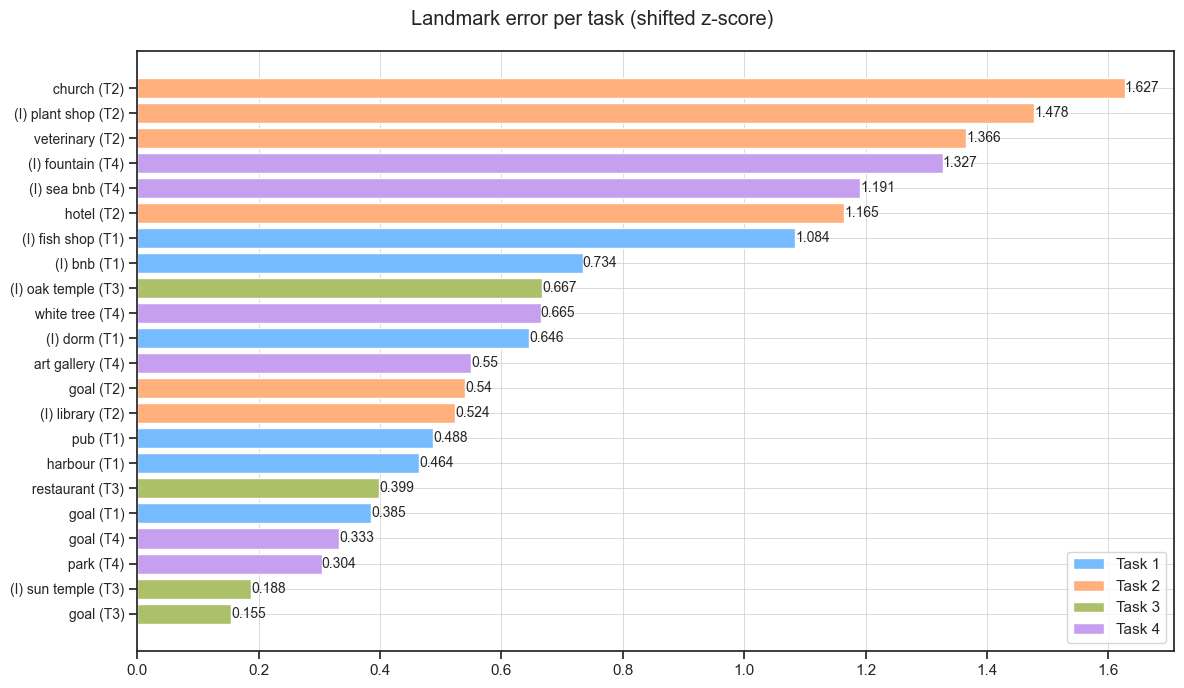

In [11]:
### === SHOW STD BAR ===
show_std = False
### ===================

zdf_sketch_shifted = zdf_sketch - zdf_sketch.min()

lm_agg = zdf_sketch_shifted.agg(['mean', 'std'], axis=1).sort_values(by='mean', ascending=True)
lm_mean = lm_agg['mean']
lm_std = lm_agg['std']
task_colors = ['xkcd:sky blue', 'xkcd:peach', 'xkcd:light olive', 'xkcd:lavender']

print(lm_mean)
labels = [f"{'(I)' if on_turn else ''} {lm} (T{task})" for task, lm, on_turn in lm_mean.index]

colors = [task_colors[int(task)-1] for task, lm, on_turn in lm_mean.index]

plt.figure(figsize=(12,7))
plt.grid(True, 'both', linewidth=0.5)
y_pos = np.arange(len(lm_mean))
bars = plt.barh(y_pos, lm_mean.values.round(3), color=colors, xerr=lm_std if show_std else None)
plt.suptitle('Landmark error per task (shifted z-score)')
plt.yticks(y_pos, labels=labels, fontsize=10)

from matplotlib.patches import Patch
legend_elements = []
for i, color in enumerate(task_colors):
    legend_elements.append(Patch(facecolor=color, label=f'Task {i+1}'))

plt.legend(handles=legend_elements, loc='lower right')
plt.bar_label(bars, fontsize=10)
plt.tight_layout()
plt.savefig('plots/lm_difficulty_per_task.png')
plt.show()
# lm_agg

### Task x Participant heatmap

Heatmap to show at the same time:
- participant performance in each task in terms of placement error
- task general average performance: we can see that task 2 and 4 are the most red, ie. the most difficult

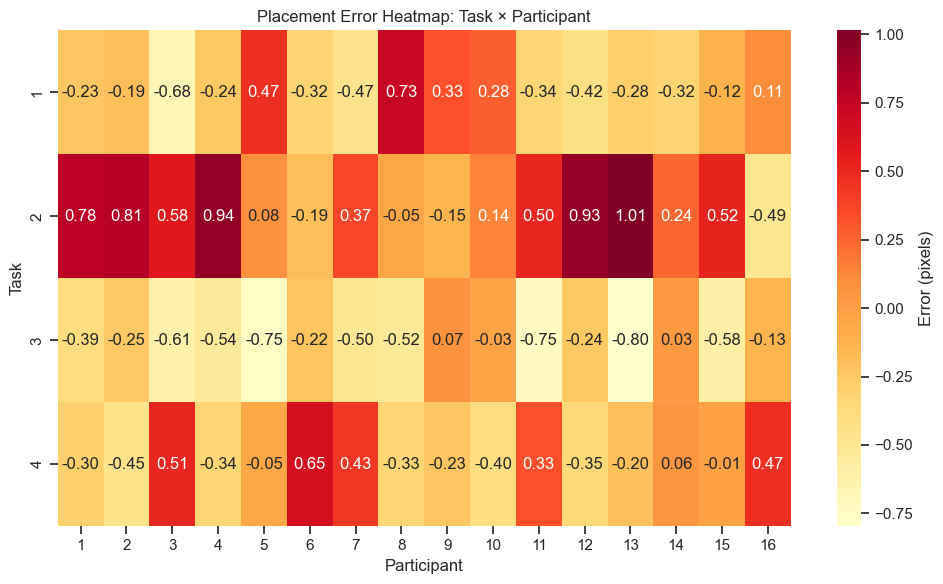

In [12]:
import seaborn as sns

task_participant = zdf_sketch.groupby(level='task').mean()
plt.figure(figsize=(10, 6))
sns.heatmap(task_participant, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Error (pixels)'})
plt.title('Placement Error Heatmap: Task × Participant')
plt.ylabel('Task')
plt.xlabel('Participant')
plt.tight_layout()
plt.savefig('plots/landmark_placement_error_participant_heatmap.png')

### Average performance per task

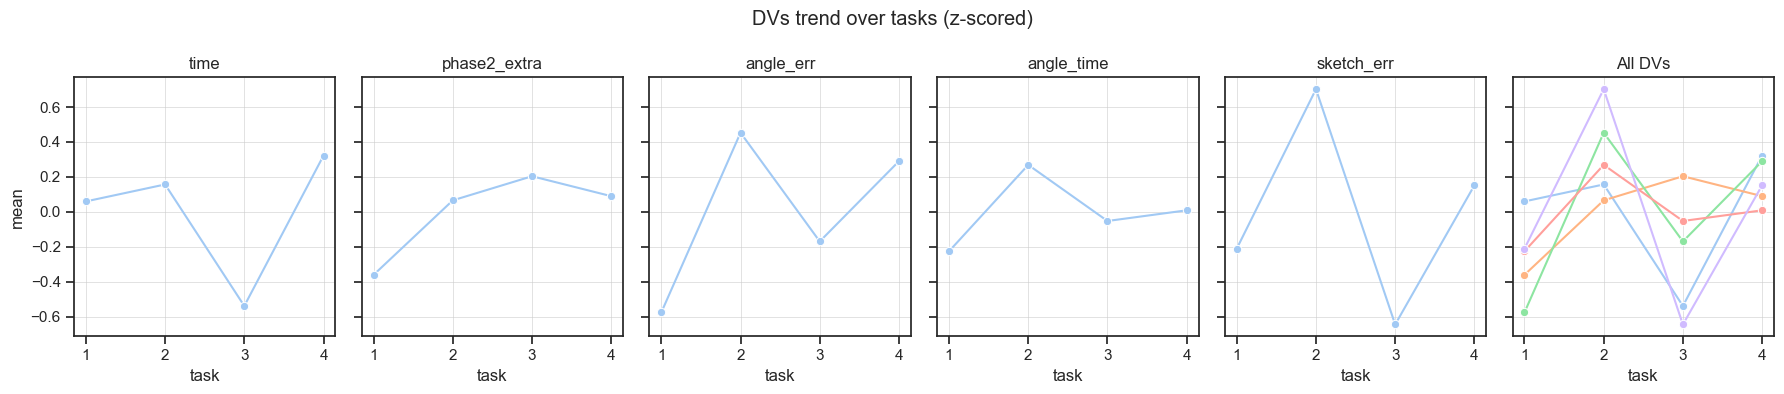

In [13]:
df_plot: pd.DataFrame = get_avg_performance(zdf_performance, ['task'])
# sns.lineplot(df_plot, x='task', y)

# sns.heatmap(df_plot.T, annot=True, center=0, cmap='cooVlwarm', cbar=False, ax=ax, fmt=".3f")
# ax.set_title('z-scored')
# ax.set_xlabel('task')
# ax.set_ylabel('metric')

# plt.suptitle('Average performance metric per task')
# plt.tight_layout()
# plt.savefig('plots/performance_per_task_heatmap.png')
# plt.show()

cols = ["time", "phase2_extra", "angle_err", "angle_time", "sketch_err"]

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=True)

for ax, col in zip(axes, cols):
    sns.lineplot(x=df_plot.index, y=df_plot[col]['mean'], marker="o", ax=ax)
    ax.set_title(col)
    ax.grid(True, linewidth=0.4)
    ax.set_xlabel("task")
    ax.set_ylabel("mean")
    sns.lineplot(x=df_plot.index, y=df_plot[col]['mean'], marker="o", ax=axes[5], legend='full')
axes[5].grid(True, linewidth=0.4)
axes[5].set_title('All DVs')

plt.suptitle('DVs trend over tasks (z-scored)')
plt.tight_layout()
plt.savefig('plots/performance_per_task.png')
plt.show()

---

## 3. Hypothesis 1 - performance

Qui le cose si fanno interessanti. Voglio plottare una serie di DV (le solite note) e vedere che andamento hanno in base a task e interfaccia. Allo stesso modo, voglio testare se i cambiamenti sono significanti.

Ho una serie di domande/aspettative che voglio testare:
- time phase 1 TBT to be faster than phase 1 LF (DV: time phase 1)
- phase 2 LF to be faster than phase 2 TBT (DV: phase2_extra)
- sketch performance LF to be better than TBT (DV: sketch_err)
- angle error and angle time LF to be better than TBT (DV: angle_err, angle_time)

e per ognuna, diverse cose da confrontare:
- DV raw data (LMM fit)
- DV senza outlier (LMM fit)
- DV in cui ho aggregato le task e confronto TBT vs LF (non-parametric t-test)
    - aggregato senza considerare la difficolta'
    - aggregato usando la media della performance con difficulty score

<br />

**Hypothesis 1:**

Landmark-focused (**LF**) interface will show 
- **better spatial knowledge acquisition**, in terms of *angle error* and *sketch accuracy*, 

compared to turn-by-turn (**TBT**) interface, and 

- a **higher increase in performance**, in terms of *navigation time*, 

in unaided return navigation.

In [14]:
def fit_lmm_and_predict(_df: pd.DataFrame, formula: str, dvs: list[str], var: str, random_eff_formula: str) -> tuple[pd.DataFrame, MixedLMResults]:
    df = _df.copy().reset_index()
    model = smf.mixedlm(formula, df, groups=df['name'], re_formula=random_eff_formula)
    result = model.fit()
    # print(result.summary())

    # TODO: this is not paramterized, always assumes I make iface and task interact
    grid = pd.DataFrame([
        {'iface': iface, 'task': task}
        for iface in df['iface'].unique()
        for task in sorted(df['task'].unique())
    ])
    grid[var] = result.predict(grid)
    grid['dv'] = var
    return grid, result
 
def plot_dv(_df: pd.DataFrame, df_pred: pd.DataFrame, var: str, title: str, savepath=None):
    df = _df.copy()
    df_raw = df.reset_index()
    df_no_out = get_df_performance_no_outlier(df, var).reset_index()
    # df_no_out = remove_outliers_inplace(_df, get_outliers_from_df(df)).reset_index()
    fig, axs = plt.subplots(1, 3, figsize=(13.5, 5))
    ymin = min(df_raw[var].mean(), df_no_out[var].mean()) - 1.25*max(df_raw[var].std(), df_no_out[var].std())
    ymax = max(df_raw[var].mean(), df_no_out[var].mean()) + 1.25*max(df_raw[var].std(), df_no_out[var].std())

    # plot 1: DV raw data
    axs[0].grid(True, alpha=0.4)
    sns.lineplot(
        data=df_raw,
        x="task",
        y=var,
        hue="iface",
        marker="o",
        ax=axs[0],
    )
    axs[0].set_xlabel("Task")
    axs[0].set_ylim(ymin, ymax)
    axs[0].set_xticks([1,2,3,4], ['1', '2', '3', '4'])
    axs[0].set_title('DV raw data')

    # plot 2: DV senza outlier
    axs[1].grid(True, alpha=0.4)
    sns.lineplot(
        data=df_no_out,
        x="task",
        y=var,
        hue="iface",
        marker="o",
        ax=axs[1],
    )
    axs[1].set_xlabel("Task")
    axs[1].set_ylim(ymin, ymax)
    axs[1].set_xticks([1,2,3,4], ['1', '2', '3', '4'])
    axs[1].set_title('DV no outliers')

    # plot 3: DV predicted by LMM
    axs[2].grid(True, alpha=0.4)
    sns.lineplot(
        data=df_pred,
        x="task",
        y=var,
        hue="iface",
        marker="o",
        ax=axs[2],
    )
    axs[2].set_xlabel("Task")
    axs[2].set_ylim(ymin, ymax)
    axs[2].set_xticks([1,2,3,4], ['1', '2', '3', '4'])
    axs[2].set_title('DV predicted by LMM')

    # # plot 4: DV generally-aggregated and weighted-aggregated (somehow)
    # df_aggr = df_performance.groupby('iface')[var].mean().round(3).rename('raw')
    # df_aggr_with_difficulty = scale_df_by_task_difficulty(df_performance).groupby('iface')[var].mean().round(3).rename('weighted')
    # df_combined = pd.concat([df_aggr, df_aggr_with_difficulty], axis=1)
    # axs[3].grid(True, alpha=0.4)
    # df_melted = df_combined.reset_index().melt(id_vars="iface", var_name="type (difficulty)", value_name=var)
    # sns.barplot(data=df_melted, x="type (difficulty)", y=var, hue="iface", ax=axs[3], hue_order=['tbt', 'lf'])
    # axs[3].set_title('DV aggregated')

    plt.suptitle(title)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    plt.show()

Per testare la significance 
- cerco di fittare una LMM, e mi prendo cura delle interazione tra interfaccia e task
- se ho aggreagto per task, mi ritrovo con solo due gruppi "indipendenti" LF vs TBT; non essendo normali, uso un test non-parametrico (Mann-Whitney U) e comparo le due interfacce come se i partecipanti avessero giocato una sola task
    - LF vs TBT con i dati raw
    - LF vs TBT con i dati senza outlier
    - LF vs TBT con i dati scalati a seconda della difficolta'

In [15]:
# this code is a mess of if/else and optional conditions cause i just wanted one function to call to show stuff
# it basically does Mann Whiteney U between LF-TBT for the provided df

def lf_vs_tbt_significance(df: pd.DataFrame, var: str, phase=None, title: str='-', eye: bool=False):
    if eye:
        df = df.copy().reset_index().set_index(['name', 'task', 'iface', 'aoi'])
    else:
        df = df.copy().reset_index().set_index(['name', 'task', 'phase', 'iface'])

    if var in ['angle_err', 'angle_time']:
        if not phase:
            # no phase specified means that we are examining both
            for phase in [1, 2]:
                lf = df.loc[:, :, phase, 'lf'][var].values
                tbt = df.loc[:, :, phase, 'tbt'][var].values
                stat, p = stats.mannwhitneyu(lf, tbt, alternative='two-sided')
                print(f"{'(*) ' if p<0.05 else ''}{var} phase {phase}, LF vs TBT p={p:.3f} ({title})")
        else:
            # in this case, phase is specified
            lf = df.loc[:, :, phase, 'lf'][var].values
            tbt = df.loc[:, :, phase, 'tbt'][var].values
            stat, p = stats.mannwhitneyu(lf, tbt, alternative='two-sided')
            print(f"{'(*) ' if p<0.05 else ''}{var} phase {phase}, LF vs TBT p={p:.3f} ({title})")
    else:
        if eye:
            lf = df.loc[:, :, 'lf', :][var].values
            tbt = df.loc[:, :, 'tbt', :][var].values
            stat, p = stats.mannwhitneyu(lf, tbt, alternative='two-sided')
            print(f"{'(*) ' if p<0.05 else ''}{var}, lf vs tbt p={p:.3f} ({title})")
        else:
            lf = df.loc[:, :, 1, 'lf'][var].values
            tbt = df.loc[:, :, 1, 'tbt'][var].values
            stat, p = stats.mannwhitneyu(lf, tbt, alternative='two-sided')
            print(f"{'(*) ' if p<0.05 else ''}{var}, lf vs tbt p={p:.3f} ({title})")

def lf_vs_tbt_significance_all(df: pd.DataFrame, title: str):
    print(f"\n=== {title} ===")
    for var in vars:
        lf_vs_tbt_significance(df, var)
    
def pretty_print_pvalues(result: MixedLMResults, debug=False):
    if debug:
        print(result.summary())
    print('\n== pvalues from LMM fit ==')
    for name, pval in result.pvalues.items():    # .items() works for Series in pandas
        label = f"{'(*) ' if pval < 0.05 else '    '}{name}"
        print(f"{label}: p = {pval:.4f}")

def pretty_print_aggregated_significance(df, var, phase=None):
    print('== aggregated significance ==')
    lf_vs_tbt_significance(df, var, phase, 'raw')
    # df_no_out = remove_outliers_inplace(df.copy(), get_outliers_from_df(df))
    # lf_vs_tbt_significance(get_df_performance_no_outlier(df, var) , var, phase, 'no-outlier')
    lf_vs_tbt_significance(scale_df_by_task_difficulty(df), var, phase, 'task-weighted')


## Aggregated DFs - paired

(*) phase1_time has p=0.010
phase2_extra has p=0.088
sketch_err has p=0.669
angle_err, learning phase, has p=0.469
angle_err, recall phase, has p=0.518
angle_time, learning phase, has p=0.551
angle_time, recall phase, has p=0.350


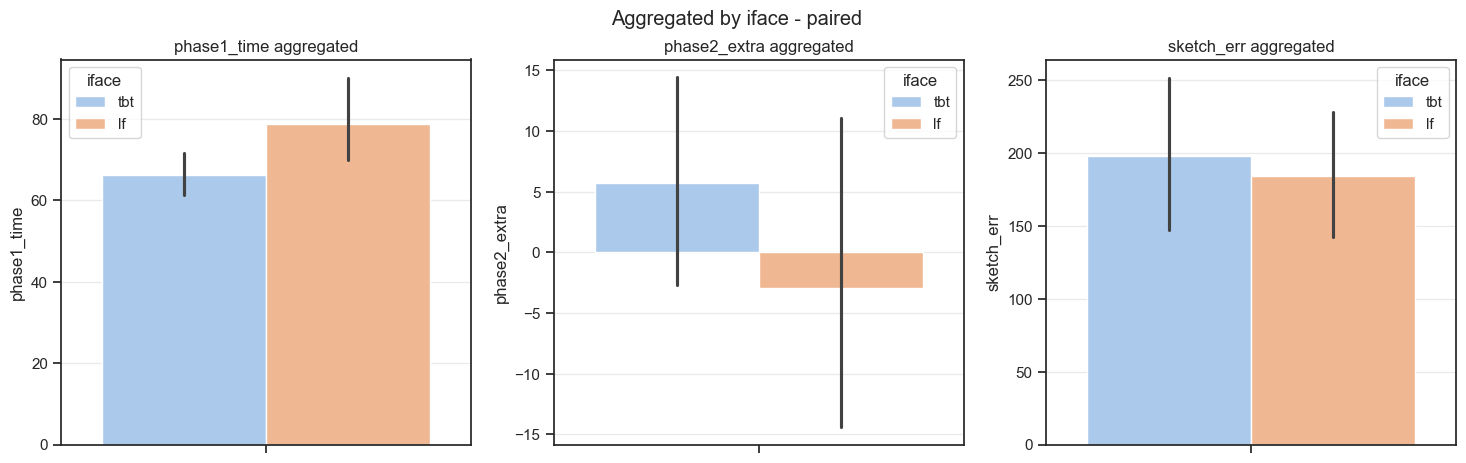

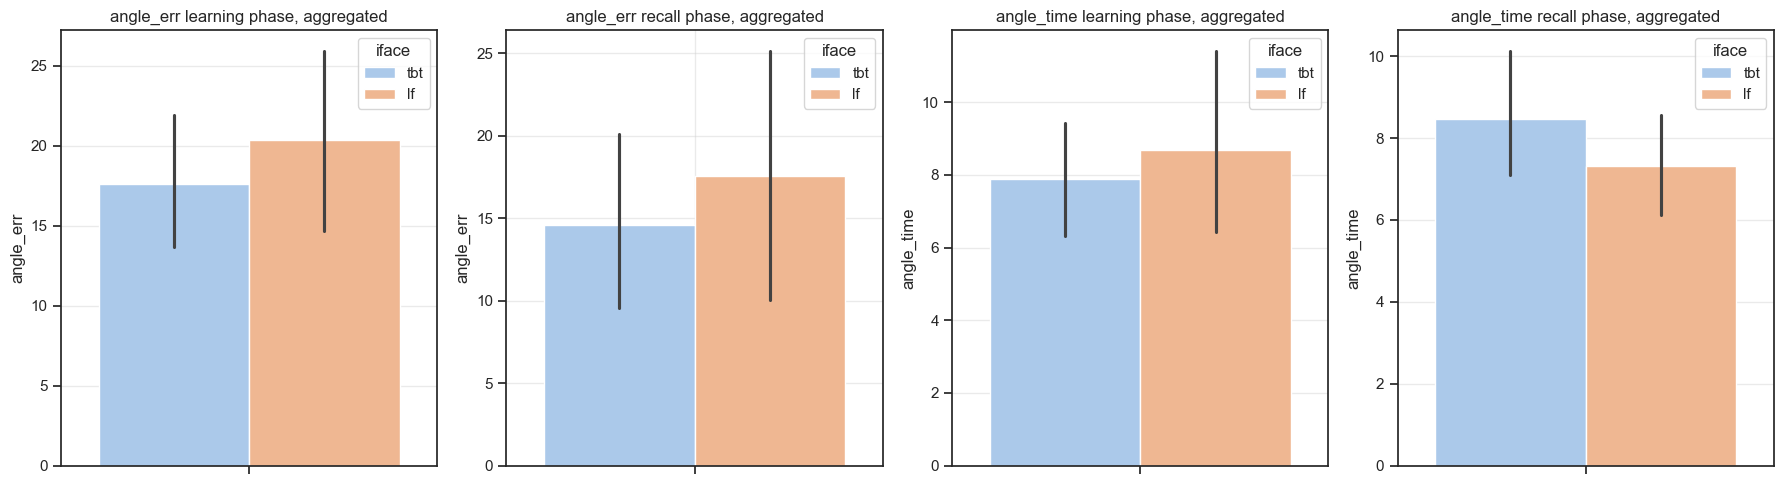

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(['phase1_time', 'phase2_extra', 'sketch_err']):
    participant_means = df_performance.groupby(['name', 'iface'])[var].mean()
    # participant_means = scale_df_by_task_difficulty(df_performance).groupby(['name', 'iface'])[var].mean()
    unstacked = participant_means.unstack()
    df = participant_means.rename(var).to_frame()

    axs[i].grid(True, alpha=0.4)
    sns.barplot(data=df, hue='iface', y=var, ax=axs[i], hue_order=['tbt', 'lf'])
    axs[i].set_title(f'{var} aggregated')
    
    # significance
    stat, pvalue = stats.wilcoxon(unstacked['lf'], unstacked['tbt'])
    print(f"{'(*) ' if pvalue <= 0.05 else ''}{var} has p={pvalue:0.3f}")

plt.suptitle('Aggregated by iface - paired')

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
p1 =  df_performance.reset_index()[df_performance.reset_index()['phase']==1]
p2 =  df_performance.reset_index()[df_performance.reset_index()['phase']==2]

for i, var in enumerate(['angle_err', 'angle_time']):
    axs[i*2].grid(True, alpha=0.4)
    axs[i*2+1].grid(True, alpha=0.4)
    
    means_p1 = p1.groupby(['name', 'iface'])[var].mean()
    means_p2 = p2.groupby(['name', 'iface'])[var].mean()
    # means_p1 = scale_df_by_task_difficulty(p1).groupby(['name', 'iface'])[var].mean()
    # means_p2 = scale_df_by_task_difficulty(p2).groupby(['name', 'iface'])[var].mean()

    unstacked_p1 = means_p1.unstack()
    df_p1 = means_p1.rename(var).to_frame()
    unstacked_p2 = means_p2.unstack()
    df_p2 = means_p2.rename(var).to_frame()

    axs[i].grid(True, alpha=0.4)
    sns.barplot(data=df_p1, hue='iface', y=var, ax=axs[i*2], hue_order=['tbt', 'lf'])

    sns.barplot(data=df_p2, hue='iface', y=var, ax=axs[i*2+1], hue_order=['tbt', 'lf'])

    stat, pvalue = stats.wilcoxon(unstacked_p1['lf'], unstacked_p1['tbt'])
    print(f"{'(*) ' if pvalue <= 0.05 else ''}{var}, learning phase, has p={pvalue:0.3f}")

    stat, pvalue = stats.wilcoxon(unstacked_p2['lf'], unstacked_p2['tbt'])
    print(f"{'(*) ' if pvalue <= 0.05 else ''}{var}, recall phase, has p={pvalue:0.3f}")

    axs[i*2].set_title(f'{var} learning phase, aggregated')
    axs[i*2+1].set_title(f'{var} recall phase, aggregated')


plt.tight_layout()
plt.show()

## Aggreated DVs - unpaired
This is not actually independent i believe, as the same particpants svore in tbt and ld are clearly realted

nb.: mann-whitney only calculated on raw data
phase1_time, lf vs tbt p=0.052 (-)
(*) phase2_extra, lf vs tbt p=0.009 (-)
sketch_err, lf vs tbt p=0.768 (-)
angle_err phase 1, LF vs TBT p=0.382 (-)
angle_err phase 2, LF vs TBT p=0.809 (-)
angle_time phase 1, LF vs TBT p=0.925 (-)
angle_time phase 2, LF vs TBT p=0.254 (-)


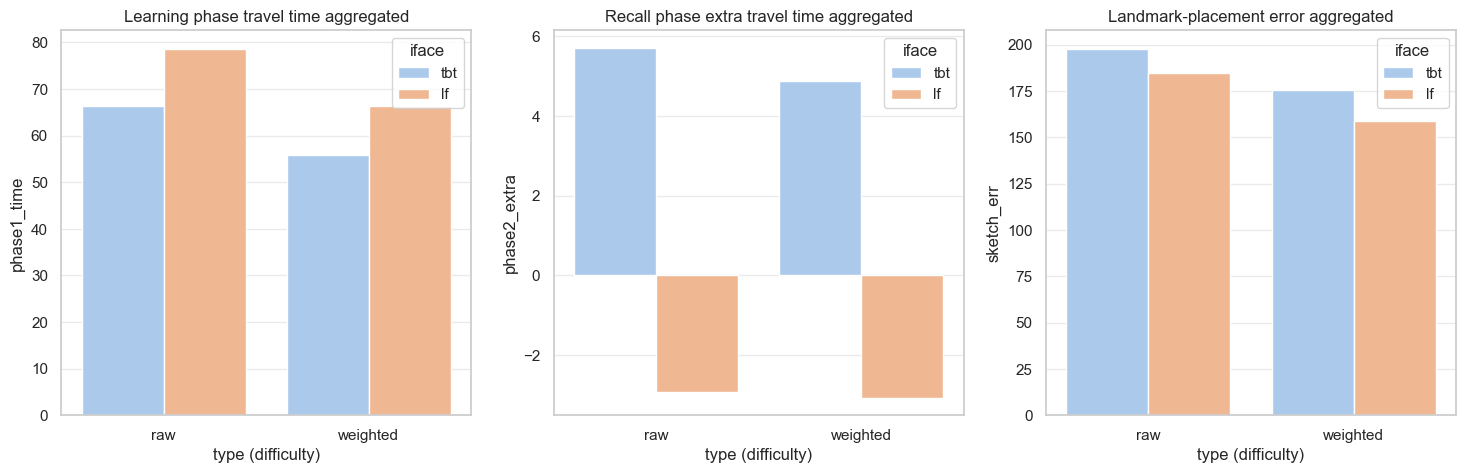

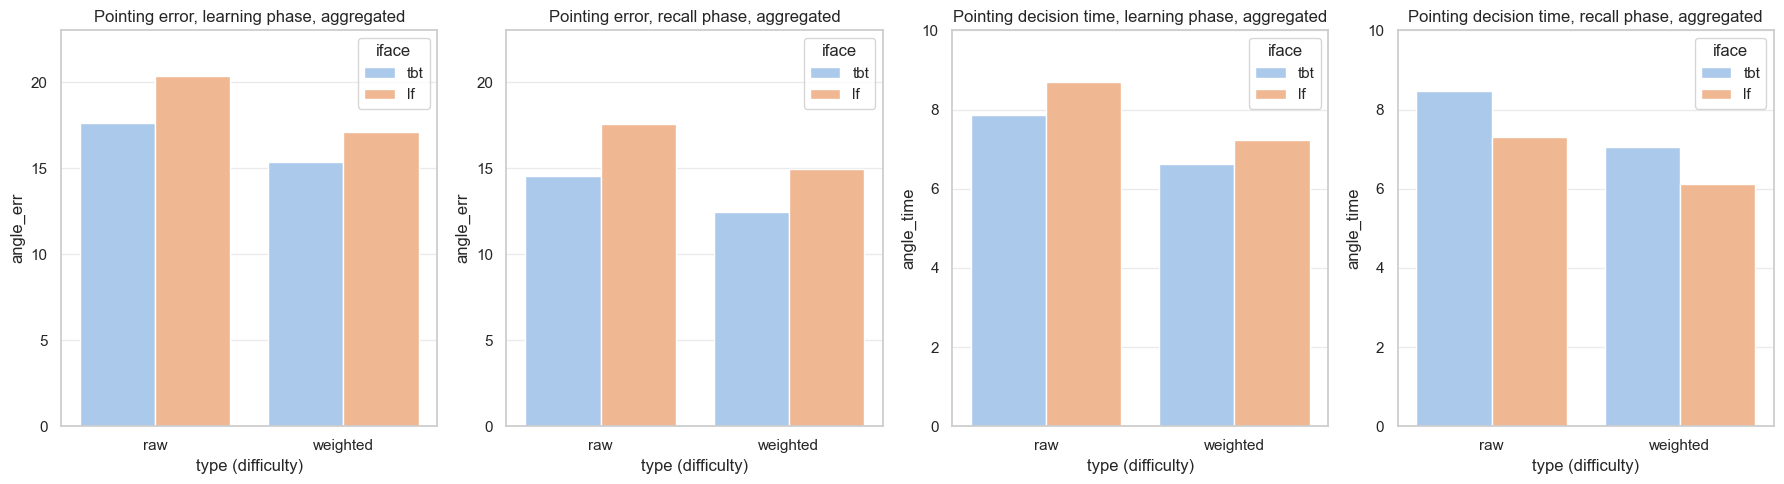

In [34]:
print('nb.: mann-whitney only calculated on raw data')
pretty = {
   'phase1_time': 'Learning phase travel time', 'phase2_extra': 'Recall phase extra travel time', 'sketch_err': 'Landmark-placement error', 'angle_err': 'Pointing error', 'angle_time': 'Pointing decision time'
}
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
df_aggr = df_performance.groupby('iface').mean().round(3)
df_aggr_with_difficulty = scale_df_by_task_difficulty(df_performance).groupby('iface').mean().round(3)

for i, var in enumerate(['phase1_time', 'phase2_extra', 'sketch_err']):
    ymin = min(df_aggr[var].mean(), df_aggr_with_difficulty[var].mean()) - 1.25*max(df_aggr[var].std(), df_aggr_with_difficulty[var].std())
    ymax = max(df_aggr[var].mean(), df_aggr_with_difficulty[var].mean()) + 1.25*max(df_aggr[var].std(), df_aggr_with_difficulty[var].std())

    axs[i].grid(True, alpha=0.4)
    df_combined = pd.concat([df_aggr[var].rename('raw'), df_aggr_with_difficulty[var].rename('weighted')], axis=1)
    df_melted = df_combined.reset_index().melt(id_vars="iface", var_name="type (difficulty)", value_name=var)
    sns.barplot(data=df_melted, x="type (difficulty)", y=var, hue="iface", ax=axs[i], hue_order=['tbt', 'lf'])
    axs[i].set_title(f'{pretty[var]} aggregated')
    lf_vs_tbt_significance(df_performance, var)

# plt.suptitle('Aggregated')

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
p1 =  df_performance.reset_index()[df_performance.reset_index()['phase']==1]
p2 =  df_performance.reset_index()[df_performance.reset_index()['phase']==2]

df_phase1 = p1.groupby('iface').mean(numeric_only=True).round(3)
df_phase1_with_difficulty = scale_df_by_task_difficulty(p1).groupby('iface').mean(numeric_only=True).round(3)

df_phase2 = p2.groupby('iface').mean(numeric_only=True).round(3)
df_phase2_with_difficulty = scale_df_by_task_difficulty(p2).groupby('iface').mean(numeric_only=True).round(3)

for i, var in enumerate(['angle_err', 'angle_time']):
    axs[i*2].grid(True, alpha=0.4)
    axs[i*2+1].grid(True, alpha=0.4)

    if var == 'angle_err':
        axs[i*2].set_ylim(0, 23)
        axs[i*2+1].set_ylim(0, 23)
    else:
        axs[i*2].set_ylim(0, 10)
        axs[i*2+1].set_ylim(0, 10)

    df_combined = pd.concat([df_phase1[var].rename('raw'), df_phase1_with_difficulty[var].rename('weighted')], axis=1)
    df_melted = df_combined.reset_index().melt(id_vars="iface", var_name="type (difficulty)", value_name=var)
    sns.barplot(data=df_melted, x="type (difficulty)", y=var, hue="iface", ax=axs[i*2], hue_order=['tbt', 'lf'])
    axs[i*2].set_title(f'{pretty[var]}, learning phase, aggregated')

    df_combined = pd.concat([df_phase2[var].rename('raw'), df_phase2_with_difficulty[var].rename('weighted')], axis=1)
    df_melted = df_combined.reset_index().melt(id_vars="iface", var_name="type (difficulty)", value_name=var)

    sns.barplot(data=df_melted, x="type (difficulty)", y=var, hue="iface", ax=axs[i*2+1], hue_order=['tbt', 'lf'])
    axs[i*2+1].set_title(f'{pretty[var]}, recall phase, aggregated')

    lf_vs_tbt_significance(p1, var, phase=1)
    lf_vs_tbt_significance(p2, var, phase=2)

plt.tight_layout()
plt.show()

### H1.1 [DV: TIME] does phase 1 take less time in TBT?
Making sure TBT interface works - ie., phase 1 is faster in TBT

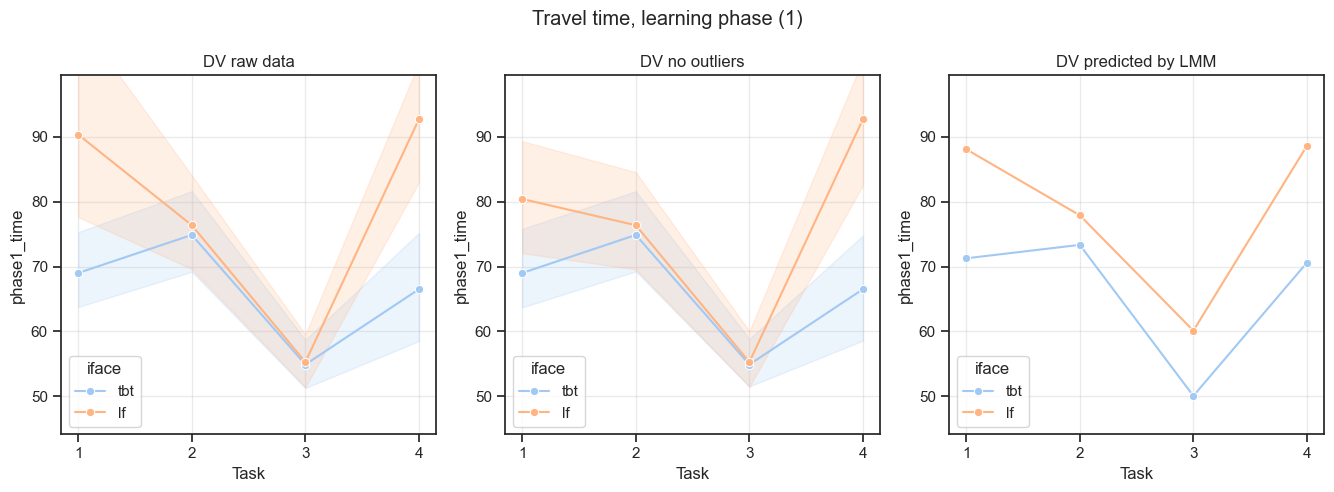

                  Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      phase1_time
No. Observations:        128          Method:                  REML       
No. Groups:              16           Scale:                   110.3292   
Min. group size:         8            Log-Likelihood:          -483.9058  
Max. group size:         8            Converged:               Yes        
Mean group size:         8.0                                              
--------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                     88.107    4.608 19.122 0.000  79.077  97.138
C(iface)[T.tbt]              -16.840    4.314 -3.903 0.000 -25.295  -8.384
C(task)[T.2]                 -10.200    4.091 -2.494 0.013 -18.217  -2.183
C(task)[T.3]                 -28.011    4.09

In [18]:
var = 'phase1_time'
df_pred, result = fit_lmm_and_predict(df_performance, formula=f"{var} ~ C(iface) * C(task)", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_performance, df_pred, var, "Travel time, learning phase (1)", savepath='plots/results_phase1_time.png')

pretty_print_pvalues(result, debug=True)


### H1.2 [DV: extra_time] is Phase 2 faster in LF?

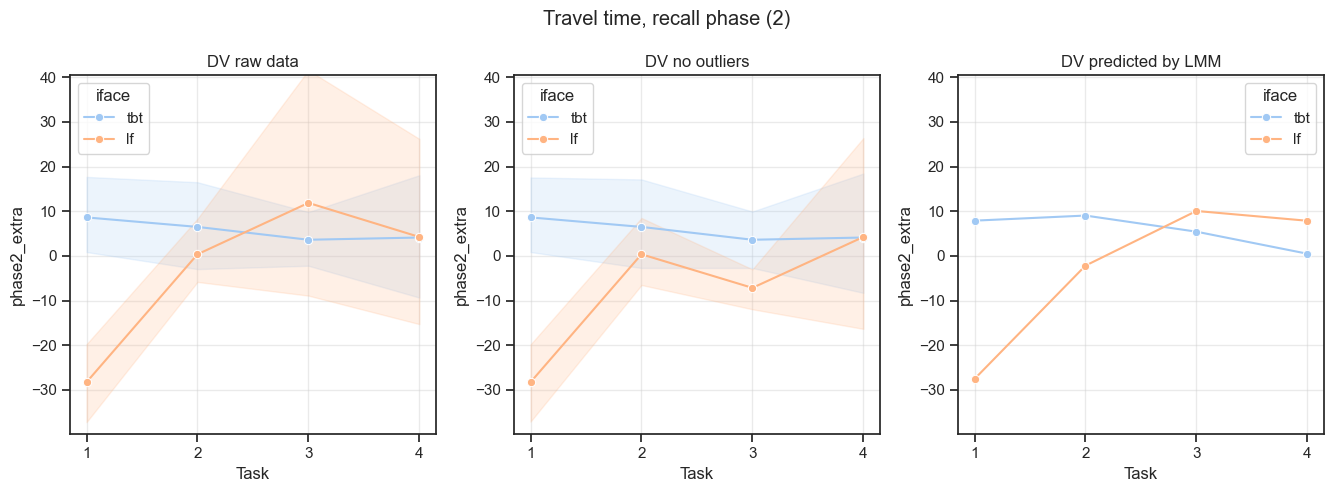

                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      phase2_extra
No. Observations:       128          Method:                  REML        
No. Groups:             16           Scale:                   716.3884    
Min. group size:        8            Log-Likelihood:          -583.7290   
Max. group size:        8            Converged:               Yes         
Mean group size:        8.0                                               
--------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                    -27.526    7.809 -3.525 0.000 -42.832 -12.221
C(iface)[T.tbt]               35.428   10.446  3.392 0.001  14.955  55.901
C(task)[T.2]                  25.360   10.104  2.510 0.012   5.556  45.165
C(task)[T.3]                  37.593   10.09

In [19]:
var = 'phase2_extra'
df_pred, result = fit_lmm_and_predict(df_performance, formula=f"{var} ~ C(iface) * C(task)", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_performance, df_pred, var, "Travel time, recall phase (2)", savepath='plots/results_phase2_time.png')

pretty_print_pvalues(result, debug=True)

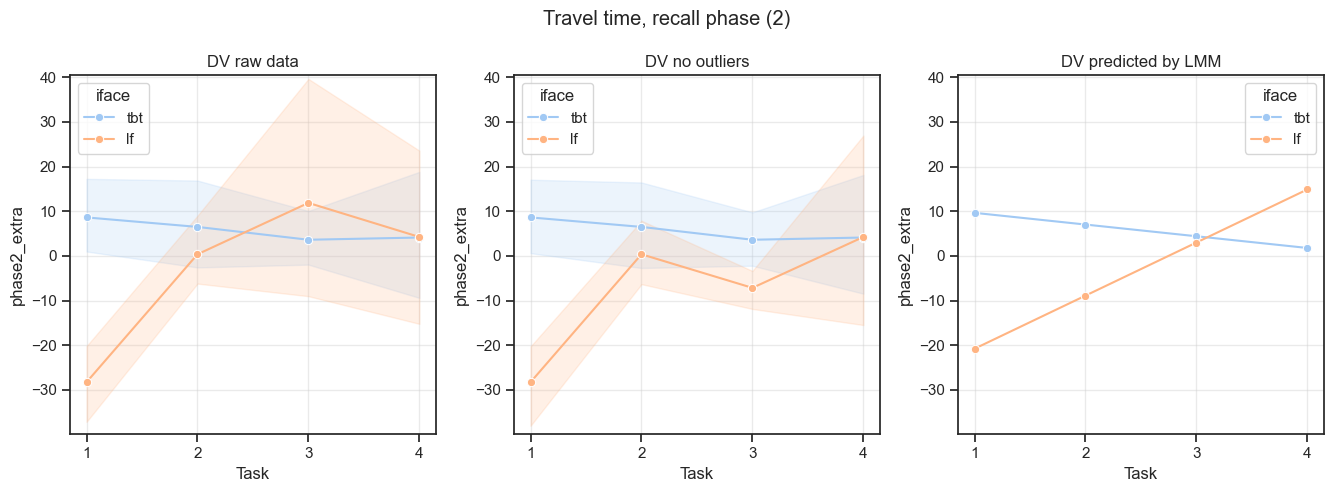

              Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   phase2_extra
No. Observations:     128       Method:               REML        
No. Groups:           16        Scale:                712.2029    
Min. group size:      8         Log-Likelihood:       -600.3466   
Max. group size:      8         Converged:            Yes         
Mean group size:      8.0                                         
------------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept            -32.644    9.442 -3.457 0.001 -51.151 -14.138
C(iface)[T.tbt]       44.914   13.179  3.408 0.001  19.082  70.745
task                  11.883    3.242  3.666 0.000   5.529  18.236
C(iface)[T.tbt]:task -14.503    4.922 -2.946 0.003 -24.151  -4.855
Group Var            197.558    4.199                             


== pvalu

In [20]:
var = 'phase2_extra'
df_pred, result = fit_lmm_and_predict(df_performance, formula=f"{var} ~ C(iface) * task", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_performance, df_pred, var, "Travel time, recall phase (2)", savepath='plots/results_phase2_time.png')

pretty_print_pvalues(result, debug=True)

### H1.3 [DV: sketch_error] is sketch performance better in LF?

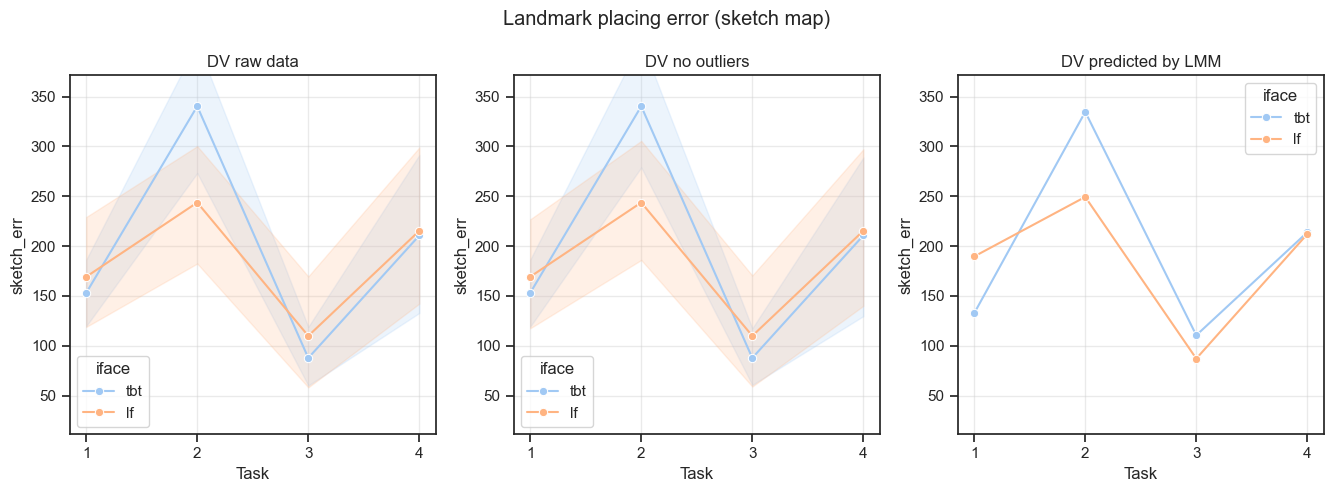

                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       sketch_err
No. Observations:         128           Method:                   REML      
No. Groups:               16            Scale:                    10345.7032
Min. group size:          8             Log-Likelihood:           -748.4383 
Max. group size:          8             Converged:                Yes       
Mean group size:          8.0                                               
----------------------------------------------------------------------------
                              Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------------
Intercept                     189.535   33.401  5.675 0.000  124.071 254.999
C(iface)[T.tbt]               -56.966   41.078 -1.387 0.166 -137.477  23.545
C(task)[T.2]                   59.737   39.025  1.531 0.126  -16.750 136.224
C(task)[T.3]       

In [21]:
var = 'sketch_err'
df_pred, result = fit_lmm_and_predict(df_performance, formula=f"{var} ~ C(iface) * C(task)", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_performance, df_pred, var, "Landmark placing error (sketch map)", savepath='plots/results_sketch_err.png')

pretty_print_pvalues(result, debug=True)

### H1.4 [DV: angle_err] is angle performance better in LF?

Outlier not found removing (10, 2, 2) for variable angle_err. If it is about phase, you can ignore...


/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


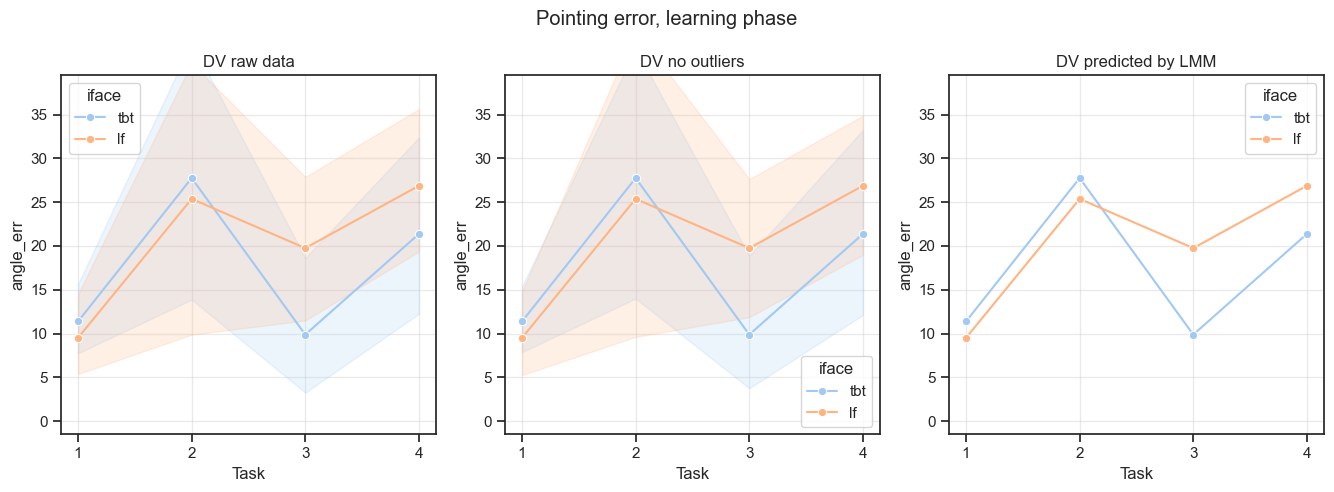

angle error phase 1
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       angle_err
No. Observations:       64            Method:                   REML     
No. Groups:             16            Scale:                    242.6853 
Min. group size:        4             Log-Likelihood:           -241.5478
Max. group size:        4             Converged:                Yes      
Mean group size:        4.0                                              
-------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      9.500    5.519  1.721 0.085  -1.317 20.317
C(iface)[T.tbt]                1.875    7.821  0.240 0.811 -13.455 17.205
C(task)[T.2]                  15.875    7.800  2.035 0.042   0.586 31.164
C(task)[T.3]                  10.250

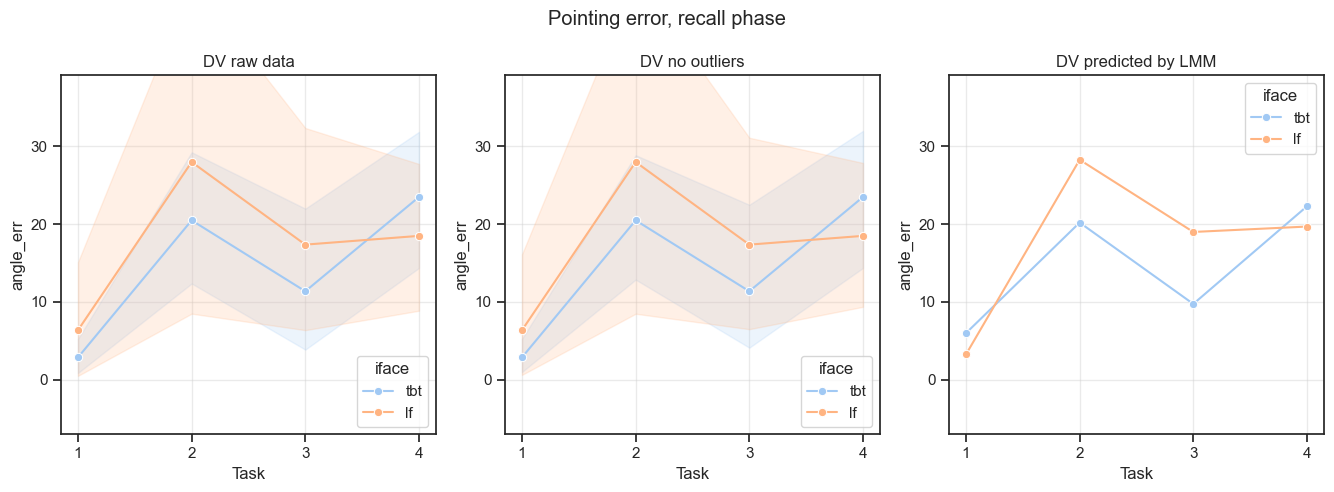

angle error phase 2
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       angle_err
No. Observations:       64            Method:                   REML     
No. Groups:             16            Scale:                    222.8763 
Min. group size:        4             Log-Likelihood:           -245.9149
Max. group size:        4             Converged:                Yes      
Mean group size:        4.0                                              
-------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      3.258    6.105  0.534 0.594  -8.709 15.224
C(iface)[T.tbt]                2.734    8.452  0.324 0.746 -13.832 19.301
C(task)[T.2]                  25.032    7.986  3.134 0.002   9.379 40.684
C(task)[T.3]                  15.746

In [22]:
df_phase1 = df_performance.reset_index()[df_performance.reset_index()['phase']==1]
df_phase2 = df_performance.reset_index()[df_performance.reset_index()['phase']==2]
var = 'angle_err'

df_pred, result_angle_err = fit_lmm_and_predict(df_phase1, formula=f"{var} ~ C(iface) * C(task)", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_phase1, df_pred, var, "Pointing error, learning phase", savepath='plots/results_angle_error_phase1.png')
print('angle error phase 1')
pretty_print_pvalues(result_angle_err, debug=True)

df_pred, result_angle_err = fit_lmm_and_predict(df_phase2, formula=f"{var} ~ C(iface) * C(task)", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_phase2, df_pred, var, "Pointing error, recall phase", savepath='plots/results_angle_error_phase2.png')
print('angle error phase 2')
pretty_print_pvalues(result_angle_err, debug=True)

### H1.4 [DV: angle_time] is angle time better in LF?

Outlier not found removing (8, 4, 1) for variable angle_time. If it is about phase, you can ignore...


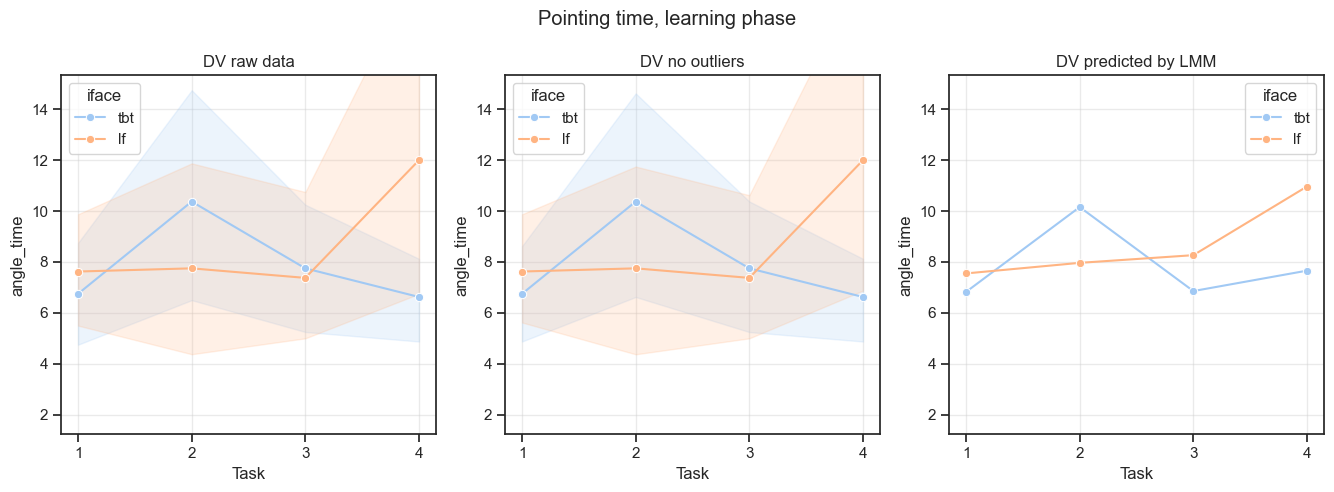

angle time phase 1
                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      angle_time
No. Observations:       64           Method:                  REML      
No. Groups:             16           Scale:                   23.3769   
Min. group size:        4            Log-Likelihood:          -182.7074 
Max. group size:        4            Converged:               Yes       
Mean group size:        4.0                                             
------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------
Intercept                     7.550    1.942  3.889 0.000   3.745 11.356
C(iface)[T.tbt]              -0.726    2.640 -0.275 0.783  -5.900  4.448
C(task)[T.2]                  0.416    2.558  0.163 0.871  -4.598  5.429
C(task)[T.3]                  0.717    2.578  0.27

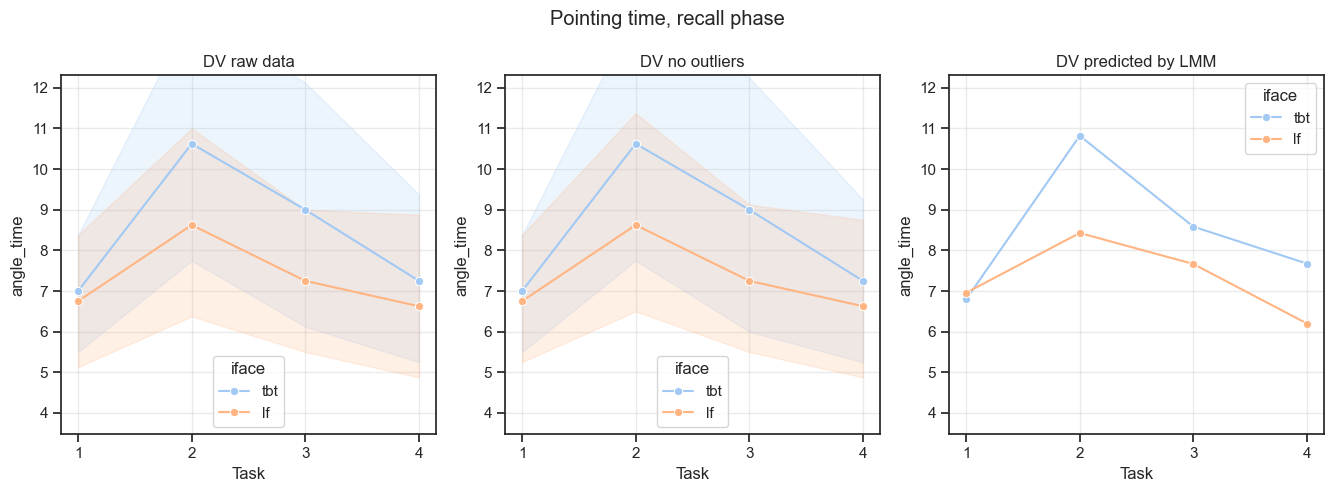

angle time phase 2
                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      angle_time
No. Observations:      64           Method:                  REML      
No. Groups:            16           Scale:                   8.4001    
Min. group size:       4            Log-Likelihood:          -154.5762 
Max. group size:       4            Converged:               Yes       
Mean group size:       4.0                                             
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     6.957    1.179  5.899 0.000  4.646  9.268
C(iface)[T.tbt]              -0.164    1.596 -0.103 0.918 -3.292  2.965
C(task)[T.2]                  1.471    1.544  0.953 0.341 -1.555  4.497
C(task)[T.3]                  0.709    1.539  0.461 0.645 -2.3

In [23]:
df_phase1 = df_performance.reset_index()[df_performance.reset_index()['phase']==1]
df_phase2 = df_performance.reset_index()[df_performance.reset_index()['phase']==2]
var = 'angle_time'

df_pred, result_angle_time = fit_lmm_and_predict(df_phase1, formula=f"{var} ~ C(iface) * C(task)", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_phase1, df_pred, var, "Pointing time, learning phase", savepath='plots/results_angle_time_phase1.png')
print('angle time phase 1')
pretty_print_pvalues(result_angle_time, debug=True)

df_pred, result_angle_time = fit_lmm_and_predict(df_phase2, formula=f"{var} ~ C(iface) * C(task)", dvs=['iface', 'task'], var=var, random_eff_formula='~1')
plot_dv(df_phase2, df_pred, var, "Pointing time, recall phase", savepath='plots/results_angle_time_phase2.png')
print('angle time phase 2')
pretty_print_pvalues(result_angle_time, debug=True)

### How does it correlate with their self-reported measures?

Text(0.5, 0.98, 'Correlation performance - self-reported skills')

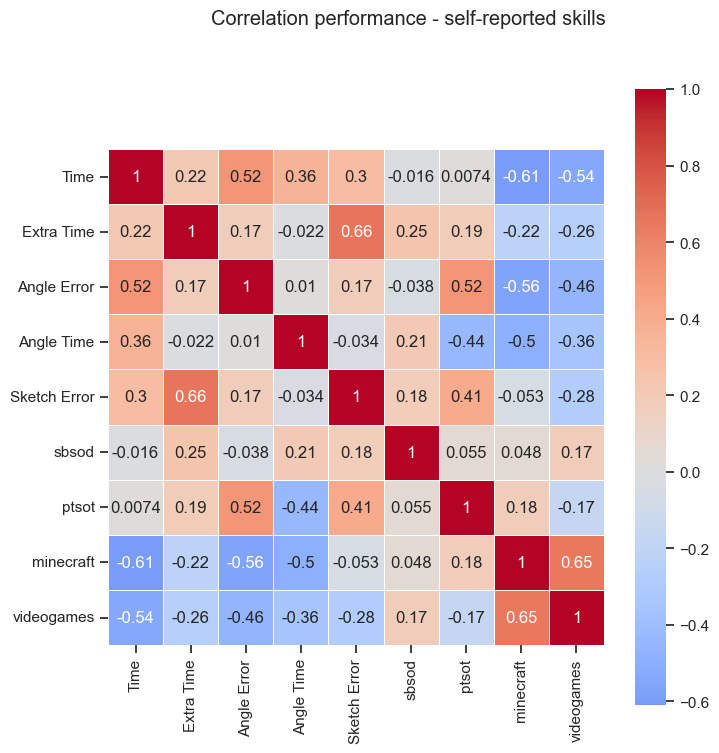

In [24]:
from copy import copy
avg_perf_participant: pd.DataFrame = get_avg_performance(df_performance, ['name'])
avg_perf_participant.columns = ['Time', 'Extra Time', 'Angle Error', 'Angle Time', 'Sketch Error']
corr_matrix = pd.concat([avg_perf_participant, df_general], axis=1).drop(columns=['task1',	'iface1',	'task2',	'iface2',	'task3',	'iface3',	'task4',	'iface4']).corr('spearman')
fig, ax = plt.subplots(figsize=(8,8))
ax.grid(True, linewidth=0.2)
mask = (corr_matrix < 0.25) & (corr_matrix > -0.25)

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, annot=True, linewidths=0.5, ax=ax)
plt.suptitle("Correlation performance - self-reported skills")
# plt.savefig('plots/correlation_performance_skills.png')

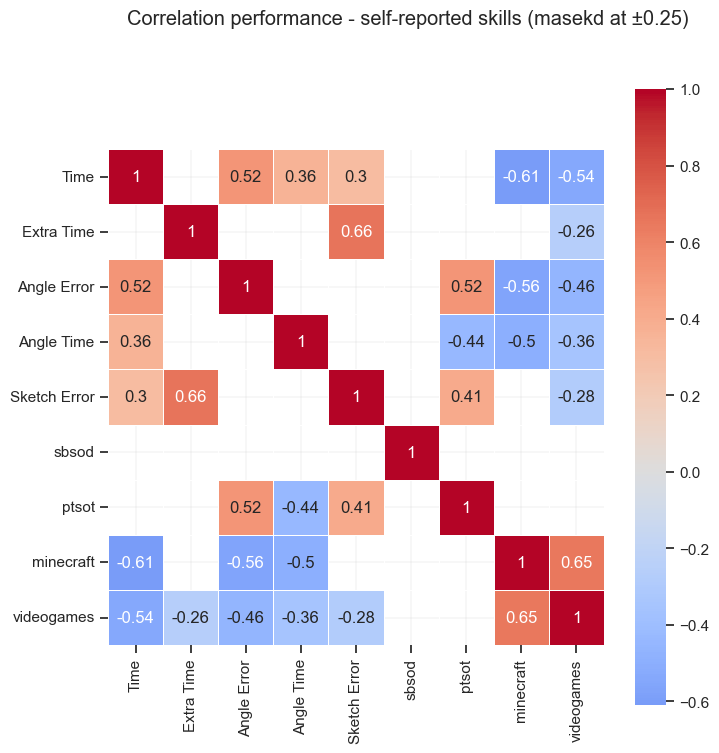

In [25]:
fig, ax = plt.subplots(figsize=(8,8))
ax.grid(True, linewidth=0.2)
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, square=True, annot=True, linewidths=0.5, ax=ax)
plt.suptitle("Correlation performance - self-reported skills (masekd at ±0.25)")
# plt.savefig('plots/correlation_performance_skills_masked.png')
plt.show()

between DVs:
- time is positively correlated with every DVs: the more time it takes to complete a task, the higher the angle error (0.61) and sketch error (0.57) will be; angle time is negligible
- extra time is of course positively correlated with time, as is calculated starting from it; a higher extra time will show a higher angle error (0.38) and a higher sketch error (0.55)
- angle error and angle time are weakly negatively correlated: the more time it takes to choose, the more accurate the angle will be, but it's a somewhat weak correlation

what is the correlation between the DVs and 
- minecraft and videogames playing: 
    - the more you play minecraft, the less time it takes you in general (-0.53) and in phase 2 (-0.51); same for videogames but stronger for general (-0.7) compared to phase 2 (-0.34)
    - the more you play, the better your pointing skills (error: -0.54, time: -0.32); similarly in vidoegames
    - the more you play, a little bit better gets your sketch error (-0.18); bit better in videogames (-0.32)
    - minecraft playing is positively correlated with videogames playing (it is: you dont have a case where minecraft > videogames)
- PTSOT
    - a high PTSOT value, ie. a worse mental rotation, correlates with a high time in general (0.56) and small impact on extra time (0.06)
    - bad mental rotation correlates with higher angle error (0.59), but lower angle time (-0.38); angle time is probably due to confidence in own's skills instead?
    - bad mental rotation also correlates with higher sketch error (0.42)
- SBSOD:
    - SBSOD impact on time and phase 2 time is negligible (-0.09 and 0.06)
    - same goes for angle error (-0.14) and angle time (0.15)
    - there's a bit of negative correlation with sketch error (-0.27), so a lower sense of direction would lower sketch accuracy

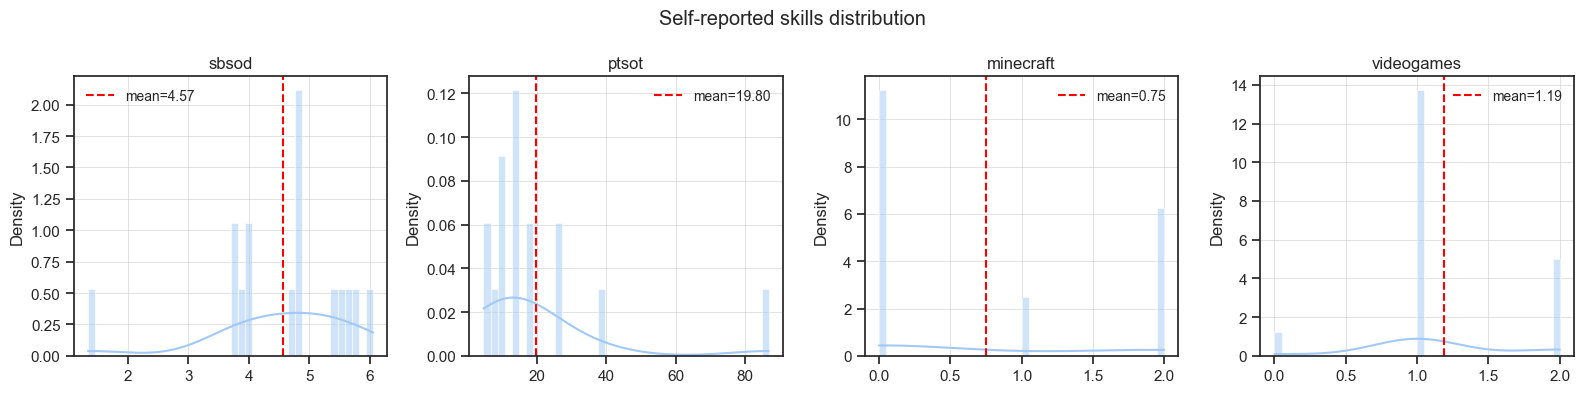

In [26]:
def hist_subplots(df, columns, bins=30, kde=True, figsize=(12, 8),
                  ncols=3, sharex=False, sharey=False, show_mean=True,
                  mean_color='red', savepath=None):
    """
    Plot histograms for `columns` from DataFrame `df` arranged in subplots.

    Parameters
    - df: pandas.DataFrame
    - columns: list of column names (strings)
    - bins: int or sequence for histogram bins
    - kde: bool, whether to draw seaborn KDE over the hist
    - figsize: tuple
    - ncols: number of columns in the subplot grid
    - sharex/sharey: bool
    - show_mean: bool, draw vertical mean line
    - mean_color: color for the mean line
    - savepath: str or None, path to save the figure (directory will be created if missing)
    """
    n = len(columns)
    if n == 0:
        raise ValueError("No columns provided.")
    import math
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize,
                             sharex=sharex, sharey=sharey)
    # axes may be 2D array even for 1 row; flatten and keep only first n axes
    axes_flat = np.array(axes).reshape(-1) if isinstance(axes, (list, np.ndarray)) else np.array([axes])
    for ax in axes_flat[n:]:
        ax.set_visible(False)

    for i, col in enumerate(columns):
        ax = axes_flat[i]
        data = df[col].dropna()
        if data.size == 0:
            ax.text(0.5, 0.5, f'No data for {col}', ha='center', va='center')
            ax.set_title(col)
            continue
        sns.histplot(data, bins=bins, kde=kde, ax=ax, stat='density', color='C0')
        if show_mean:
            mu = data.mean()
            ax.axvline(mu, color=mean_color, linestyle='--', linewidth=1.5, label=f'mean={mu:.2f}')
            ax.legend(frameon=False, fontsize='small')
        ax.set_title(col)
        ax.set_xlabel('')
        ax.set_ylabel('Density' if kde else 'Count')
        ax.grid(True, linewidth=0.4)
    plt.suptitle('Self-reported skills distribution')
    plt.tight_layout()
    if savepath:
        savedir = os.path.dirname(savepath)
        if savedir and not os.path.exists(savedir):
            os.makedirs(savedir, exist_ok=True)
        plt.savefig(savepath, bbox_inches='tight', dpi=300)
    plt.show()
    return fig

cols = ['sbsod', 'ptsot', 'minecraft', 'videogames']  # replace with your variables
fig = hist_subplots(df_general, cols, bins=40, kde=True, ncols=4, figsize=(16,4), show_mean=True, mean_color='red', savepath='plots/skills_histograms.png')

## 4. Hypothesis 2 - Eye tracking

**TBT** and **LF** interfaces will present **different eye-tracking patterns**, with the former one (TBT) showing 
- a **higher fixation frequency** on the navigation *interface* 
- a **lower frequency** on the *environment*.


### H2. Does TBT show a higher number of fixation and fixation duration on minimap AOI?
nb: direction is not supposed to be shown in LF, but there was a bug in the code that would sometimes trigger one direction box to appear in LF in task 3. it's irrelevant in any case.

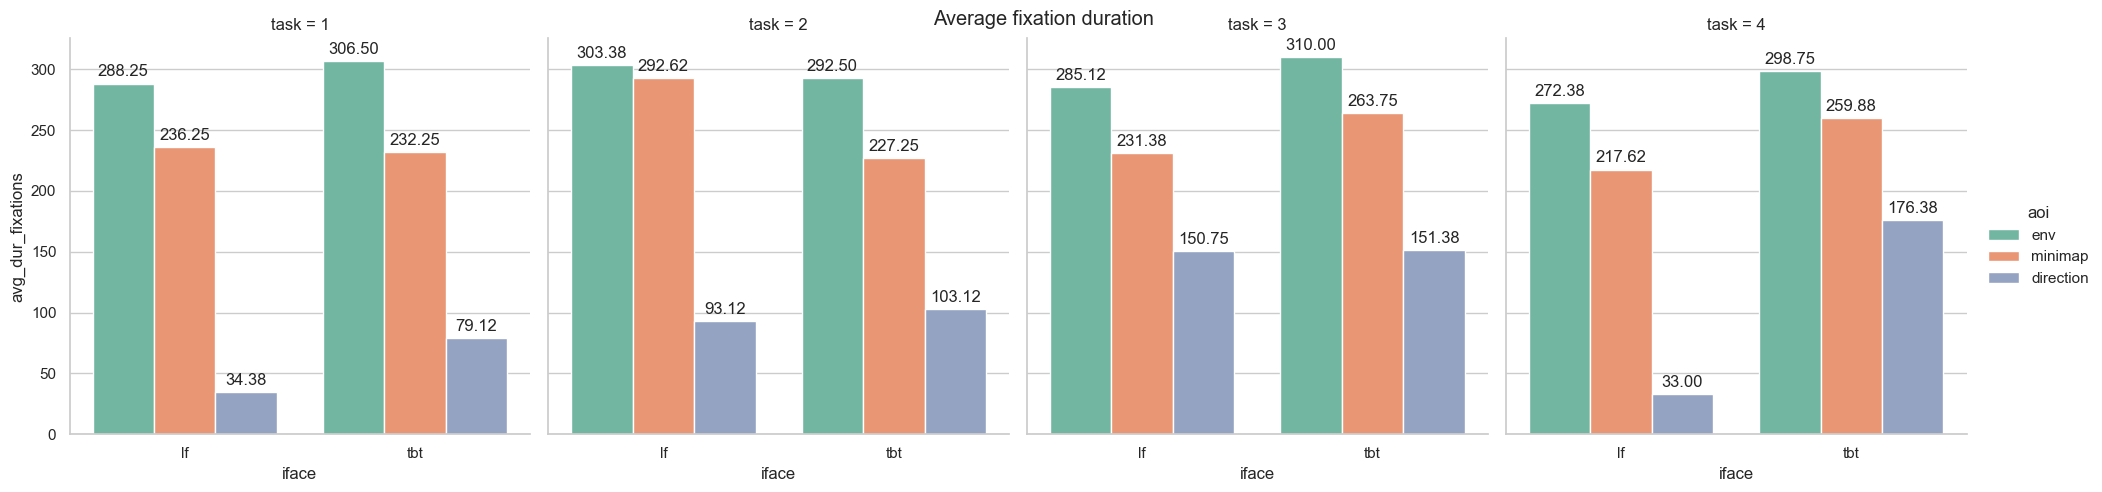

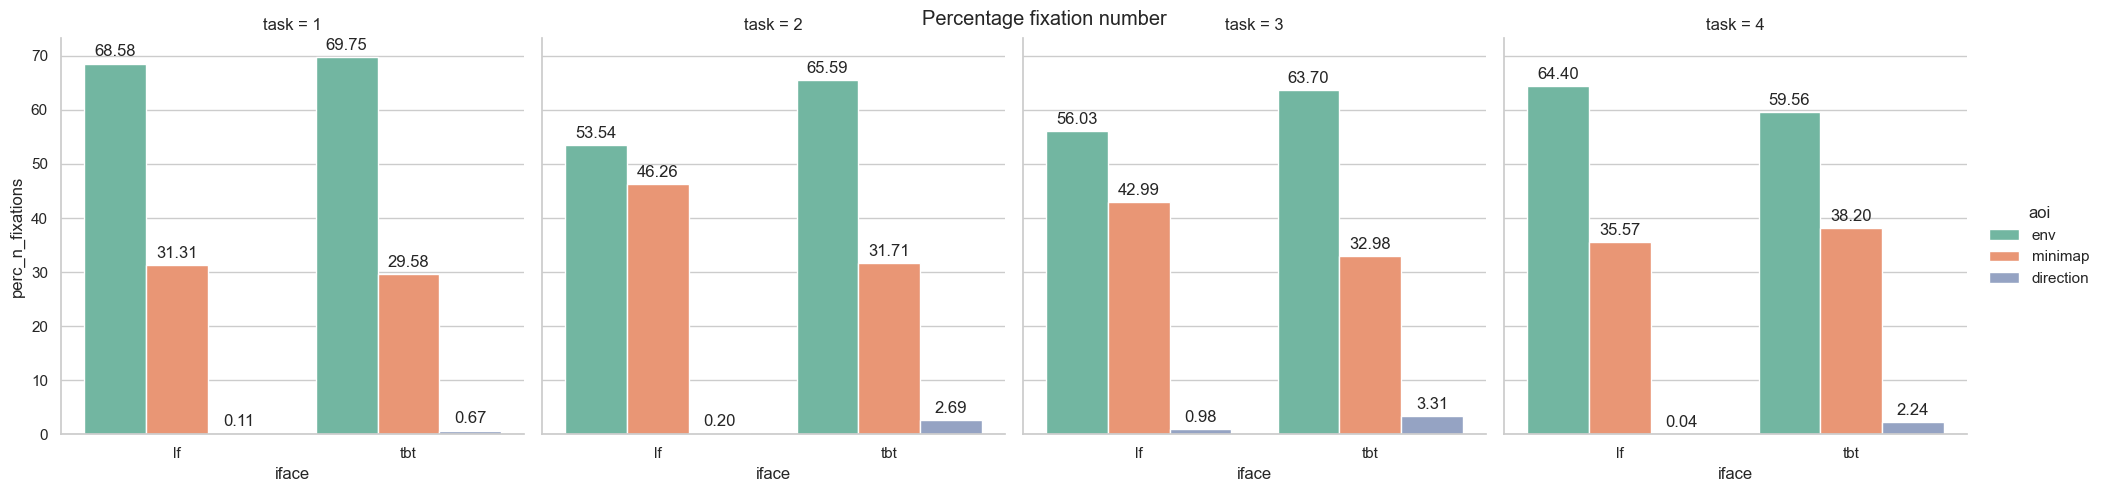

In [27]:
df_fixations_ed = df_fixations
df_fixations_ed  = df_fixations_ed.groupby(['task', 'iface', 'aoi' ]).agg('mean').round(3)

sns.set_style('whitegrid')
g = sns.catplot(
   data=df_fixations_ed,
   kind='bar',
   col="task",
   x='iface',
   y='avg_dur_fixations',
   hue="aoi",
   hue_order=['env', 'minimap', 'direction'],
   palette="Set2"
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f',  
                      padding=3)
plt.suptitle("Average fixation duration")
plt.savefig('plots/gaze_fixation_duration.png')
plt.show()

sns.set_style('whitegrid')
g = sns.catplot(
   data=df_fixations_ed,
   kind='bar',
   col="task",
   x='iface',
   y='perc_n_fixations',
   hue="aoi",
   hue_order=['env', 'minimap', 'direction'],
   palette="Set2"
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f',  
                      padding=3)
plt.suptitle("Percentage fixation number")
plt.savefig('plots/gaze_fixation_number.png')
plt.show()

### H2. Same as before, but aggregating tasks

perc_dur_fixations, lf vs tbt p=0.548 (-)
perc_n_fixations, lf vs tbt p=0.570 (-)


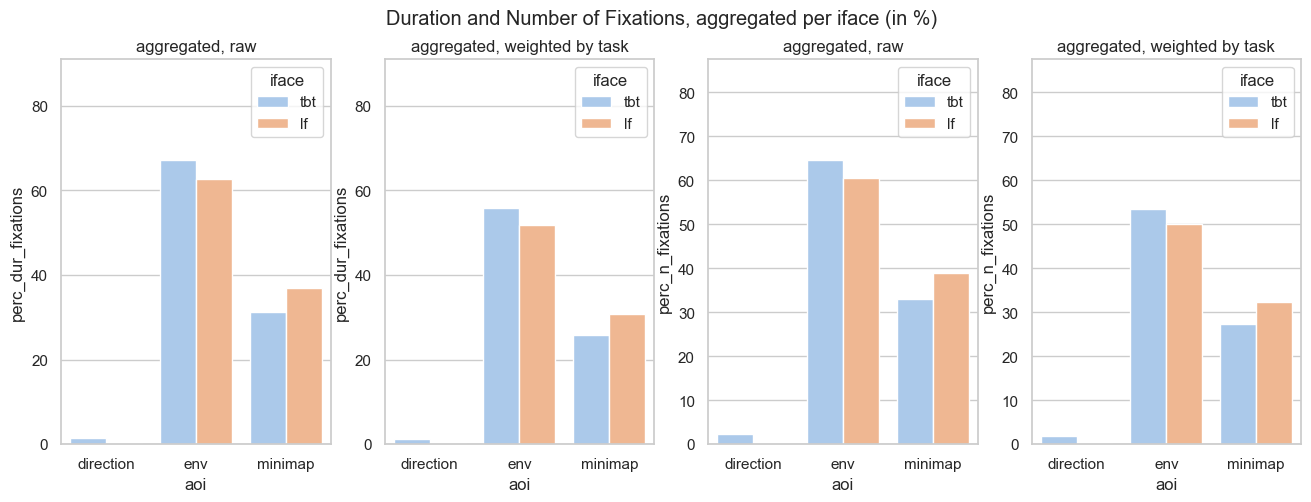

In [28]:
fig, axs = plt.subplots(1, 4, figsize=(16,5))
df_aggr = df_fixations.groupby(['iface', 'aoi']).mean().round(3)
df_aggr_with_difficulty = scale_df_by_task_difficulty(df_fixations, eye=True).groupby(['iface', 'aoi']).mean().round(3)

for i, var in enumerate(['perc_dur_fixations', 'perc_n_fixations']):
    sns.barplot(data=df_aggr, x="aoi", y=var, hue="iface", ax=axs[i*2], hue_order=['tbt', 'lf'])
    sns.barplot(data=df_aggr_with_difficulty, x="aoi", y=var, hue="iface", ax=axs[i*2+1], hue_order=['tbt', 'lf'])
    _max = max(df_aggr[var].max(), df_aggr_with_difficulty[var].max()) + min(df_aggr[var].std(), df_aggr_with_difficulty[var].std())
    axs[i*2].set_title('aggregated, raw')
    axs[i*2].set_ylim(0, _max)
    axs[i*2+1].set_title('aggregated, weighted by task')
    axs[i*2+1].set_ylim(0, _max)
    lf_vs_tbt_significance(df_fixations, var, eye=True)
plt.suptitle('Duration and Number of Fixations, aggregated per iface (in %)')
plt.show()

---

---

# 10 Nov. 2025

Cose che ci siamo detti: 
- ha senso usare le LMM: permettono di considerare gli effetti rnadom, e possono essere aggiustate per funzionare anche con modelli piu semplici, quindi e' un buon go-to
    - le LMM cosi' sono un po' inusabili: bisogna pero' aggiustarle, non usare roba random.
        - va valutato che random effects metterci, che modello usare, ... (alberto dovrebbe scrivermi prossimamente e darmi qualche consiglio)
    - i dati eye tracking sono inusabili anche loro

- un'alternativa da testare a LMM, e in generale una bella semplificazione, e' di normalizzare le task
    - se avessi una sola task, che i giocatori giocano con entrambe le interfaccem allora avrei un semplice within-subjects design, e potrei testare le due interfacce come due gruppi indipendenti.  
    - mi sembra una semplificazione importante, e su cosi pochi dati le distribuzioni probabilmente si sovrappongono parecchio, pero' vale la pena spenderci una giornata (spero meno).
    - puo' comunque aver senso aggregare le task e testare le due interfacce, come facevo prima - anche per poi confrontarlo con le task pesate
    - per normalizzare dovrei tenere conto della difficolta' di ogni task, e ho diversi modi per farlo:
        - usare i valori di difficolta' che avevo stimato io (ricavati da n. landmark + distance + n. turns) - poco accurato;
        - guardare la media della performance per ogni task, e usarla come score; pesare le task di conseguenza nell'aggregazione;
        - usare la diffcolta' dei landmark come score.

- ci sono degli outlier, e bisogna capire come gestirli; su una base di dati cosi piccola, avere dei valori outlier mi porta fuori scala e puo' avere un grosso impatto sui risultati. bisogna capire:
    - quanti sono per interfaccia, e quanti sono per task, per capire se c'e' un'interfaccia/task che e' piu' suscettibile
    - se ci sono dei partecipanti outlier ovunque, cioe che sono outlier indipendentemente dall'interfaccia e dalla task; il fattore group delle LMM dovrebbe tenere gia' conto di questa cosa pero'
    - l'idea e' che potrebbero essere outlier per un problema dell'interfaccia, o per le loro skill. Io credo sia per le skill: si perdevano.
        - la difficolta' di una task puo essere anche valutata in base a questo?
    - analisi ordinale, ranking?
    - devo identificarli, provare a rimuoverli, e vedere che effetto ha


In [29]:
df_performance.drop(columns='speed_ratio').head(4)

time  angle_err  angle_time iface  phase1_time  phase2_extra  \
name task phase                                                                 
1    1    1        80        6.0           9   tbt         80.0           4.0   
          2        84        0.0           9   tbt         80.0           4.0   
     2    1        83       32.0           4    lf         83.0          -8.0   
          2        75       35.0           8    lf         83.0          -8.0   

                 sketch_err  
name task phase              
1    1    1          54.667  
          2          54.667  
     2    1         258.500  
          2         258.500

In [30]:
df_fixations.sort_values(['name', 'task']).drop(columns=['minecraft_experience', 'ptsot', 'sbsod']).head(3)

tot_dur_fixations  avg_dur_fixations  n_fixations  \
name task aoi       iface                                                      
1    1    direction tbt                    0                0.0            0   
          env       tbt                42487              256.0          166   
          minimap   tbt                19841              320.0           62   

                           perc_dur_fixations  perc_n_fixations  
name task aoi       iface                                        
1    1    direction tbt                 0.000             0.000  
          env       tbt                68.167            72.807  
          minimap   tbt                31.833            27.193

In [31]:
df_general.head(3)

,task1,iface1,task2,iface2,task3,iface3,task4,iface4,sbsod,ptsot,minecraft,videogames
name,,,,,,,,,,,,
1,1,tbt,2,lf,3,tbt,4,lf,3.74,7.20,0,1
2,4,tbt,1,lf,2,lf,3,tbt,3.74,18.00,2,1
3,3,tbt,4,lf,1,lf,2,tbt,5.73,26.27,0,0


In [32]:
df_sketch.head(3)

1    2    3    4    5   6    7    8    9  10   11  \
task landmark  on_turn                                                       
1    bnb       True     58  167   33  176  915  78  267  353  173  13   58   
     pub       False    20  177   51  115   87  77   92  182  226   8  200   
     fish shop True     75   41  105  101  456  57  214  459  576  41  135   

                        12   13   14   15   16  
task landmark  on_turn                          
1    bnb       True     34   61  242  198  331  
     pub       False     8  244   81  244  163  
     fish shop True     78  131  892  892  459